# **Project: Economic Insights from 2022 Individual Income Tax Statistics**

**Dataset:** [Individual income tax statistics - 2022 ZIP Code data](https://www.irs.gov/pub/irs-soi/22zpallagi.csv)

**Datasource and Reference:** https://www.irs.gov/statistics/soi-tax-stats-individual-income-tax-statistics-2022-zip-code-data-soi


**Project Goal:**  Economic analysis, breakdown and classification by location (*on a State and Zipcode level*), based on 2022 individual income tax statistics in the US.

**Data Description**

ZIP Code data show selected income and tax items classified by State, ZIP Code, and size of adjusted gross income. Data are based on individual income tax returns filed with the IRS for the tax year of 2022. The data include items, such as:

- Number of returns, which approximates the number of households
- Number of personal exemptions, which approximates the population
- Adjusted gross income (AGI)
- Wages and salaries
- Dividends before exclusion
- Interest received  

ZIP Code data are based on population data that was filed and processed by the IRS during the 2023 calendar year. State codes were based on the ZIP code shown on the return.

## **I. Data Coding and Units**

* All number of returns variables have been rounded to the nearest 10.
* For all column with monetary value ($), the money amounts are reported in thousands of dollars.
* Columns with special coding:
  *  STATEFIPS: The State Federal Information Processing System (FIPS) code 01-56
  *  agi_stub: size of adjusted gross income:
      *   1 = $1 under $25,000
      *   2 = $25,000 under $50,000
      *   3 = $50,000 under $75,000
      *   4 = $75,000 under $100,000
      *   5 = $100,000 under $200,000
      *   6 = $200,000 or more
  * ZIP codes with less than 100 returns and those identified as a single building or nonresidential ZIP code were categorized as “other” (99999).
  * ZIP code "00000" represents the total value per agi_stub.

## **II. Summary:**

### Data Analysis Key Findings

*   **State-Level Income Distribution**: Washington D.C., Connecticut, and Massachusetts consistently show the highest overall average income per taxpayer. Florida, Illinois, California, Georgia, and Virginia exhibit the highest average income per AGI category (up to \$4M in Florida). New Jersey, surprisingly, has a higher percentage of taxpayers in the top AGI groups (Groups 5 and 6) compared to New York.
*   **Federal Tax Distribution**: Illinois reported the highest average federal tax (around \$1.2M), followed by Florida (>\$1M), largely mirroring states with high-income outliers. Washington D.C., Massachusetts, Rhode Island, and Connecticut have the highest median federal tax (>\$5k) when capping at \$20,000.
*   **Income Portfolio Analysis**:
    *   Salaries/wages are the primary income source across all states (generally >75%), with Texas, Louisiana, Utah, and Washington D.C. showing the highest proportions.
    *   North Dakota, Montana, and Florida have the highest percentage of income from business sources (~8%).
    *   Montana, Wyoming, and Florida show the highest percentage of income from investment sources (>5.5%).
    *   Delaware, West Virginia, and Michigan have the highest percentage of income from retirement sources (>17%).
*   **ZIP Code Segmentation Results (K-means)**: Four distinct segments were identified based on income and income portfolio:
    *   **Segment 1 (Mid-Income, High Salary Dependence)**: Average income of \$51.2K, 81.0% from salary, representing working-class households.
    *   **Segment 2 (High-Income, Investment-Oriented)**: Highest average income of \$329.0K, with 22.6% from investment, indicating affluent areas with diverse income. This is the smallest cluster (419 ZIP codes).
    *   **Segment 3 (Lower-Mid Income, Balanced with Retirement)**: Lowest average income of \$49.8K, with 20.9% from retirement, suggesting older populations. This is the largest cluster (14,953 ZIP codes).
    *   **Segment 4 (Upper-Middle Income, Salary-Dominant)**: Average income of \$77.2K, 61.0% from salary, representing well-compensated professionals.
*   **Top High-Earning ZIP Codes**: Florida (e.g., ZIP codes 33109 and 33480) and California dominate the top 60 ZIP codes by income, with Florida's high averages often driven by ultra-wealthy enclaves, potentially due to zero state income tax.

### Insights or Next Steps

*   **Targeted Marketing Opportunities**: Companies can leverage the state-level income and tax insights to target high-income consumers in states like Washington D.C., Connecticut, Massachusetts, and New Jersey. The ZIP code clusters offer a more granular approach for targeted marketing strategies, identifying specific demographic and economic profiles (e.g., investment services for Cluster 2, retirement planning for Cluster 3).
*   **Policy and Business Development Focus**: States with high proportions of business-sourced income (North Dakota, Montana, Florida) present opportunities for small business services. Similarly, states with significant retirement or investment income (Delaware, West Virginia, Michigan and cluster 3 for retirement; Montana, Wyoming, Florida or cluster 2 and 4 for investment) can be targets for specialized financial planning services, potentially addressing underserved markets.


# **III. Data Analysis and Insights**

In [126]:
install.packages("maps")
library(maps)
library(readr)
library(tidyverse)
install.packages("mapproj")
library(mapproj)
install.packages("tigris")
library(tigris)
library(sf)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [127]:
income <- read_csv("https://www.irs.gov/pub/irs-soi/22zpallagi.csv")

Rows: 166131 Columns: 165
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (3): STATEFIPS, STATE, zipcode
dbl (162): agi_stub, N1, mars1, MARS2, MARS4, ELF, CPREP, PREP, DIR_DEP, VRT...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [128]:
head(income)

STATEFIPS,STATE,zipcode,agi_stub,N1,mars1,MARS2,MARS4,ELF,CPREP,⋯,N85300,A85300,N11901,A11901,N11900,A11900,N11902,A11902,N12000,A12000
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
01,AL,00000,1,659530,422590,71000,154700,610780,24340,⋯,0,0,63060,54280,543620,1559881,541480,1552563,2250,5031
01,AL,00000,2,533640,276250,101050,141040,499310,15050,⋯,0,0,100320,130848,430380,1339883,427830,1329439,2780,8556
01,AL,00000,3,304870,134050,109980,51600,286110,9600,⋯,0,0,88750,186002,216080,585162,212990,573080,4520,12589
01,AL,00000,4,193020,56350,113100,19090,181390,4530,⋯,0,0,67040,189833,124860,403052,121760,388581,2840,12190
01,AL,00000,5,315700,45000,252660,12180,297930,9000,⋯,140,63,138270,657283,177730,748507,169080,671684,10940,80141
01,AL,00000,6,109460,7950,96190,940,103540,2220,⋯,54750,223885,59810,1634928,46530,1184029,33970,456283,13170,649409


- This database has 165 variables and 166,131 observations.

In [129]:
# Cleaning and restructuring the original dataset
income1 <- income %>%
  select(STATEFIPS:MARS4, starts_with("A00"),
         A02650, A01000, A02300, A02500, A26270, A25870, A18425, A18300, A04800,A07260, A10600, A11901, A11900, A01700, A10300, A01400)

# Create a new table structure
income1 <- income1%>%
    filter(N1 >0, zipcode != "00000", zipcode != "99999") %>% # Removing observations with 0 number of return or from the ZIP codes of "00000", "99999".
    mutate(num_of_taxpayers= N1+MARS2, aver_interest_income = (A00300+A00400)/num_of_taxpayers,
         aver_investment_income = (A00600 + A00650 + A01000)/num_of_taxpayers, aver_agi = A00100/num_of_taxpayers, aver_income = A02650/num_of_taxpayers,
         aver_salary=A00200/num_of_taxpayers, aver_state_refund=A00700/num_of_taxpayers, aver_business_income=A00900/num_of_taxpayers,
         aver_unemployment_comp = A02300/num_of_taxpayers, aver_social_security = A02500/num_of_taxpayers, aver_partnership_income = A26270/num_of_taxpayers,
         aver_rental_income = A25870/num_of_taxpayers, aver_state_income_tax=A18425/num_of_taxpayers, aver_tax_paid=A10600/num_of_taxpayers,
         aver_taxable_income=A04800/num_of_taxpayers, aver_residential_energy_credit=A07260/num_of_taxpayers, aver_fed_tax=A10300/num_of_taxpayers,
         aver_tax_owed=A11901/num_of_taxpayers, aver_overpayment=A11900/num_of_taxpayers, aver_pension = A01700/num_of_taxpayers,
         salary_percent = A00200/A02650, investment_percent = (A00600 + A00300+A00400 + A01000)/A02650, business_percent = (A00900 + A26270 + A25870)/A02650,
          retirement_percent = (A01700 + A02500 +A01400)/A02650, unemployment_percent = A02300/A02650) %>%
  # Replace NaN or Inf in percentage columns with 0
  mutate(across(c(salary_percent, investment_percent, business_percent, retirement_percent, unemployment_percent), ~ ifelse(is.nan(.) | is.infinite(.), 0, .)))

income1 <- income1 %>%
  rename(num_of_return = N1, num_single_return = mars1, num_joint_return = MARS2, num_head_return = MARS4)

income1 <- income1 %>%
  select(-starts_with("A00"), -A02650, -A01000, -A02300, -A02500, -A26270, -A25870, -A18425, -A18300, -A04800, -A07260,
         -A10600, -A11901, -A11900, -A01700, -A10300, -A01400)

In [130]:
# Dataframe after cleaning and restructuring
head(income1)

STATEFIPS,STATE,zipcode,agi_stub,num_of_return,num_single_return,num_joint_return,num_head_return,num_of_taxpayers,aver_interest_income,⋯,aver_residential_energy_credit,aver_fed_tax,aver_tax_owed,aver_overpayment,aver_pension,salary_percent,investment_percent,business_percent,retirement_percent,unemployment_percent
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
01,AL,35004,1,1260,880,150,210,1410,0.06595745,⋯,0.00000000,0.3503546,0.09148936,1.468794,1.287234,0.6975107,0.018284020,0.11625178,0.18012231,0.007844833
01,AL,35004,2,1320,770,230,280,1550,0.09032258,⋯,0.02709677,1.6303226,0.18645161,2.101290,2.690323,0.8210435,0.007066712,0.01347092,0.14490775,0.000000000
01,AL,35004,3,1000,480,320,160,1320,0.08181818,⋯,0.09393939,3.5189394,0.46515152,1.312879,3.704545,0.8185256,0.010443990,0.02069487,0.14563654,0.001383949
01,AL,35004,4,620,200,330,70,950,0.13789474,⋯,0.00000000,5.0136842,0.64000000,1.165263,3.857895,0.8219931,0.012405186,0.02742592,0.13399096,0.000000000
01,AL,35004,5,1040,130,860,50,1900,0.12263158,⋯,0.01157895,7.9578947,0.95789474,1.105789,4.460526,0.8386593,0.016980607,0.03181990,0.10883577,0.000000000
01,AL,35004,6,170,0,150,0,320,0.40000000,⋯,0.00000000,31.2000000,4.87187500,2.787500,6.937500,0.6351028,0.074329544,0.18465585,0.08635912,0.000000000


**Potential Data Conflict:**
*   Since ZIP code 99999 was removed and some tax filings aren't published by IRS (to avoid personal information interpretation of extreme wealthy taxpayers or areas with small population), any statstics driven from this dataset may not represent the true economic status of all US locations.
*   Since total income includes losses driven by business and investment activities, some Income may show a smaller number than its components (such as salary). Hence, the salary percentage of income (*salary_percent*) for example, could be larger than 100%.



In [131]:
# Create state-level stats of Income and Income Portfolio
state_average1 <- income1 %>%
  group_by(STATE) %>%
  summarize (number_of_taxpayers = sum(num_of_taxpayers),
              income = sum(aver_income * num_of_taxpayers)/sum(num_of_taxpayers),
              agi = sum(aver_agi * num_of_taxpayers)/sum(num_of_taxpayers),
              fed_tax = sum(aver_fed_tax * num_of_taxpayers)/sum(num_of_taxpayers),
              taxable_income = sum(aver_taxable_income * num_of_taxpayers)/sum(num_of_taxpayers),
              salary = sum(aver_salary * num_of_taxpayers)/sum(num_of_taxpayers),
              salary_percent = sum(salary_percent * num_of_taxpayers)/sum(num_of_taxpayers),
              investment_percent = sum(investment_percent * num_of_taxpayers)/sum(num_of_taxpayers),
              business_percent = sum(business_percent * num_of_taxpayers)/sum(num_of_taxpayers),
              retirement_percent = sum(retirement_percent * num_of_taxpayers)/sum(num_of_taxpayers),
              unemployment_percent = sum(unemployment_percent * num_of_taxpayers)/sum(num_of_taxpayers),
              total_percent = salary_percent + investment_percent + business_percent + retirement_percent + unemployment_percent)

In [132]:
# Create ZIP-level stats of Income and Income Portfolio
zip_average1 <- income1 %>%
  group_by(zipcode, STATE) %>%
  summarize (number_of_taxpayers = sum(num_of_taxpayers),
              income = sum(aver_income * num_of_taxpayers)/sum(num_of_taxpayers),
              agi = sum(aver_agi * num_of_taxpayers)/sum(num_of_taxpayers),
              fed_tax = sum(aver_fed_tax * num_of_taxpayers)/sum(num_of_taxpayers),
              taxable_income = sum(aver_taxable_income * num_of_taxpayers)/sum(num_of_taxpayers),
              salary = sum(aver_salary * num_of_taxpayers)/sum(num_of_taxpayers),
              salary_percent = sum(salary_percent * num_of_taxpayers)/sum(num_of_taxpayers),
              investment_percent = sum(investment_percent * num_of_taxpayers)/sum(num_of_taxpayers),
              business_percent = sum(business_percent * num_of_taxpayers)/sum(num_of_taxpayers),
              retirement_percent = sum(retirement_percent * num_of_taxpayers)/sum(num_of_taxpayers),
              unemployment_percent = sum(unemployment_percent * num_of_taxpayers)/sum(num_of_taxpayers),
              total_percent = salary_percent + investment_percent + business_percent + retirement_percent + unemployment_percent)

`summarise()` has grouped output by 'zipcode'. You can override using the
`.groups` argument.


## **IV. Economic and Wealth Distribution by State**

In [133]:
head(state_average1 %>%
  arrange(desc(income)))

STATE,number_of_taxpayers,income,agi,fed_tax,taxable_income,salary,salary_percent,investment_percent,business_percent,retirement_percent,unemployment_percent,total_percent
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DC,400310,114.60704,113.08374,21.80417,95.45788,76.61797,0.7893083,0.04391283,0.06479587,0.08770351,0.005005659,0.9907262
CT,2392120,92.11463,91.01766,16.25327,74.99226,57.73516,0.7126526,0.04946401,0.07106656,0.15087408,0.006805071,0.9908623
MA,4637150,90.94597,90.06848,15.45341,74.41491,59.71721,0.7286673,0.05020591,0.06980902,0.13366257,0.010007871,0.9923527
NJ,6101280,83.69765,82.77352,13.64852,66.96751,57.39065,0.7340088,0.04140775,0.07379398,0.13291820,0.009743261,0.9918720
CA,23809120,83.27641,82.46844,13.61240,66.12546,55.80361,0.7499373,0.04085447,0.08067721,0.11363834,0.009810109,0.9949174
NY,12303130,82.82668,82.00608,14.13476,66.15579,52.77340,0.7267551,0.04058227,0.08053207,0.13958061,0.008009333,0.9954594


### A. Income Distribution

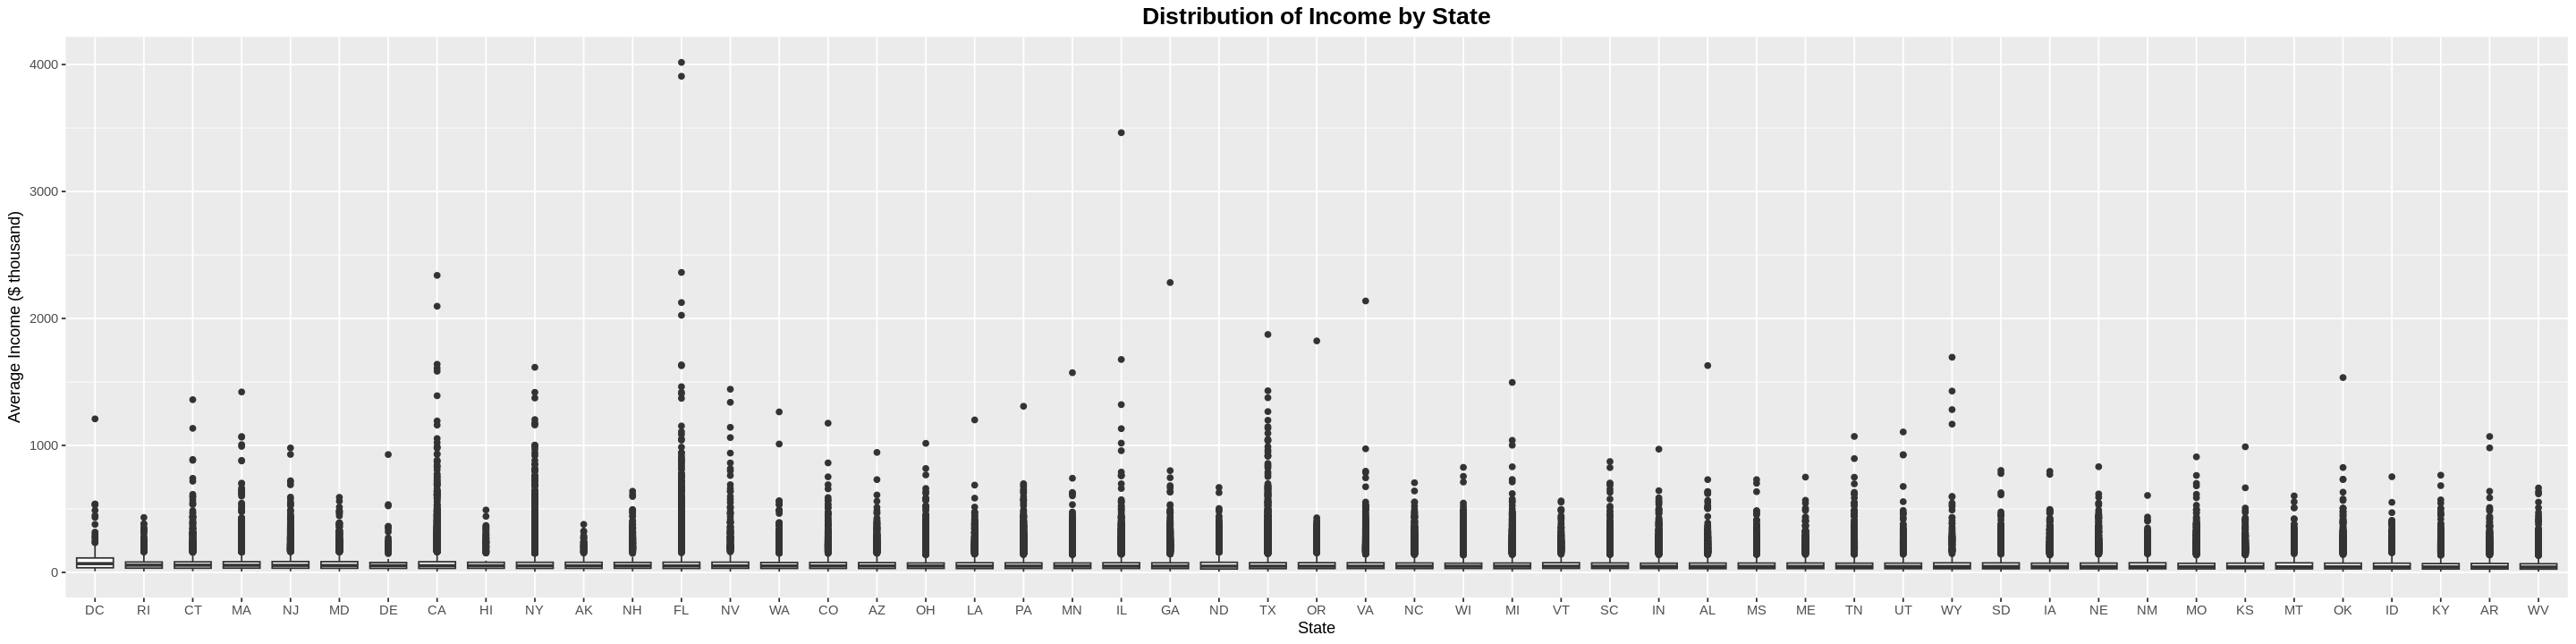

In [134]:
options(repr.plot.width = 24, repr.plot.height = 6)
income1 %>%
  ggplot(aes(x=fct_reorder(STATE, aver_income, .fun = median, .desc = TRUE), y = aver_income)) + geom_boxplot() + labs(x="State", y="Average Income ($ thousand)", title="Distribution of Income by State") +
   theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

- When looking at distribution of income per state, there seems to be a lot of outliers with high income value. The State of Florida has the highest value of average income per AGI category, going up to \$4M. Illinois is the next state with the 3rd highest income (~$3.5M), followed by several high income in the states of California, Florida, Georgia and Virginia.

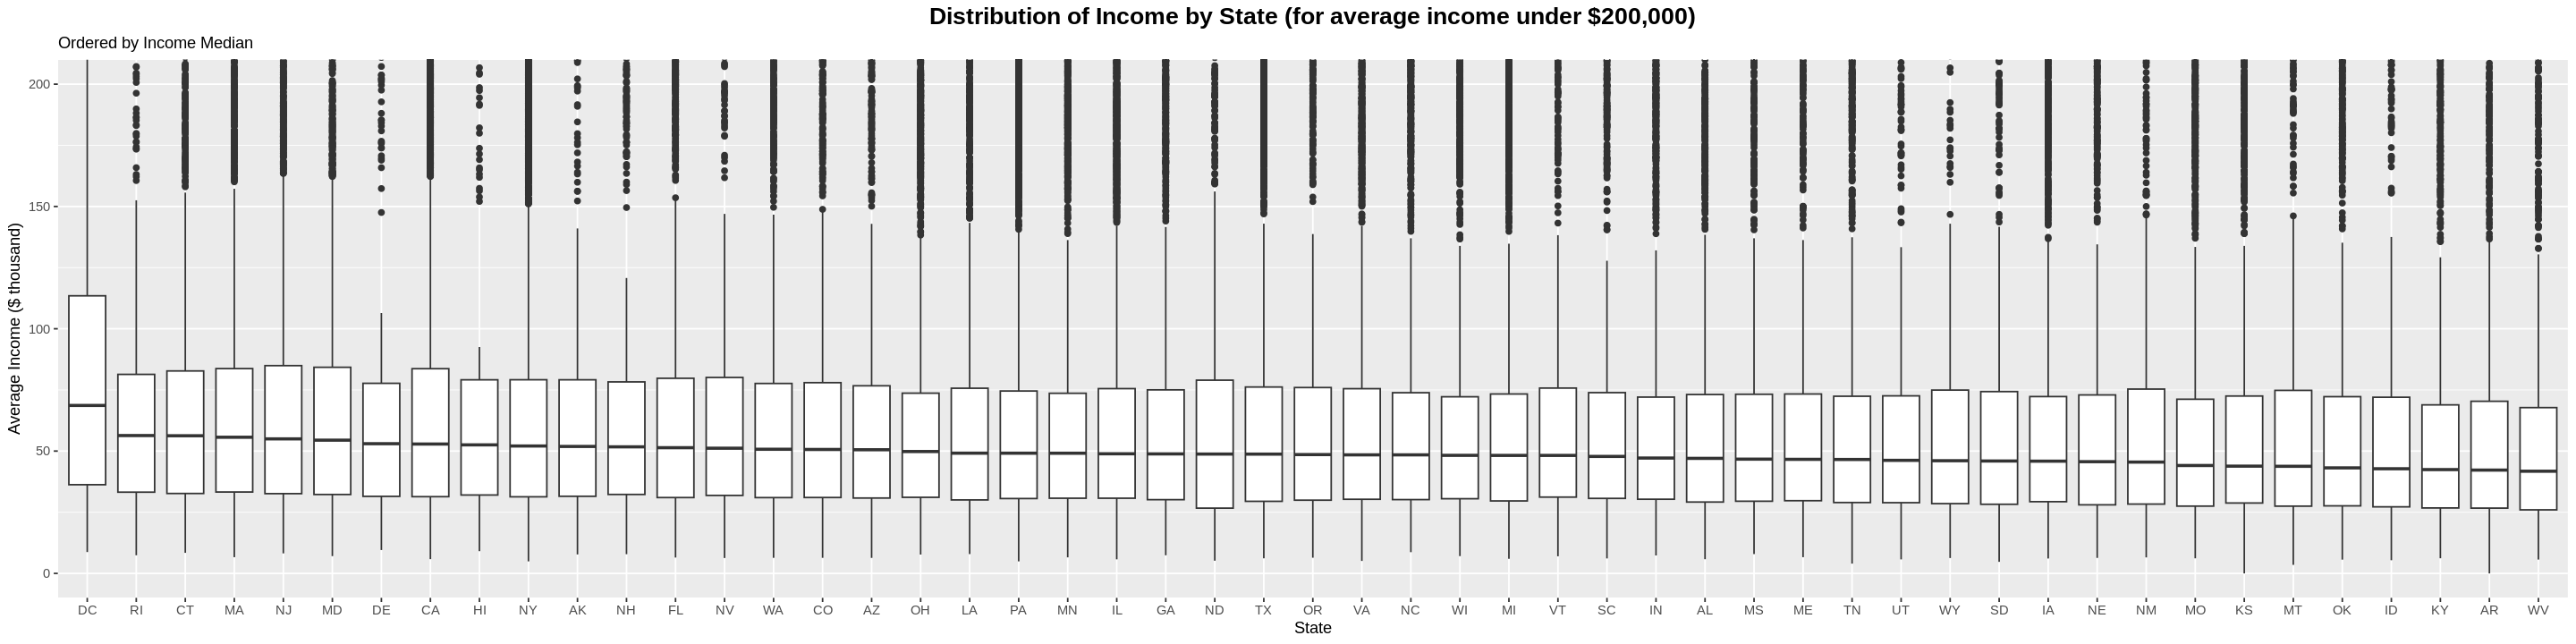

In [135]:
income1 %>%
  ggplot(aes(x=fct_reorder(STATE, aver_income, .fun = median, .desc = TRUE), y = aver_income)) + geom_boxplot() +
  labs(x="State", y="Average Income ($ thousand)", title="Distribution of Income by State (for average income under $200,000)", subtitle="Ordered by Income Median") +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold")) +
  coord_cartesian(ylim = c(0, 200))

- When zooming in to the average income per AGI under \$200,000 (AGI Groups 1-5), DC has the highest median of income, followed by Rhode Island, Connecticut and Massachutsetts.
- West Virginia has the lowest median income, followed by Arizona and Kentucky. North Dakota seems to have the biggest range of income distribution.
- The majority of Income in each state are within AGI Groups 2 and 3 (\$25,000 - $75,000), except for DC.


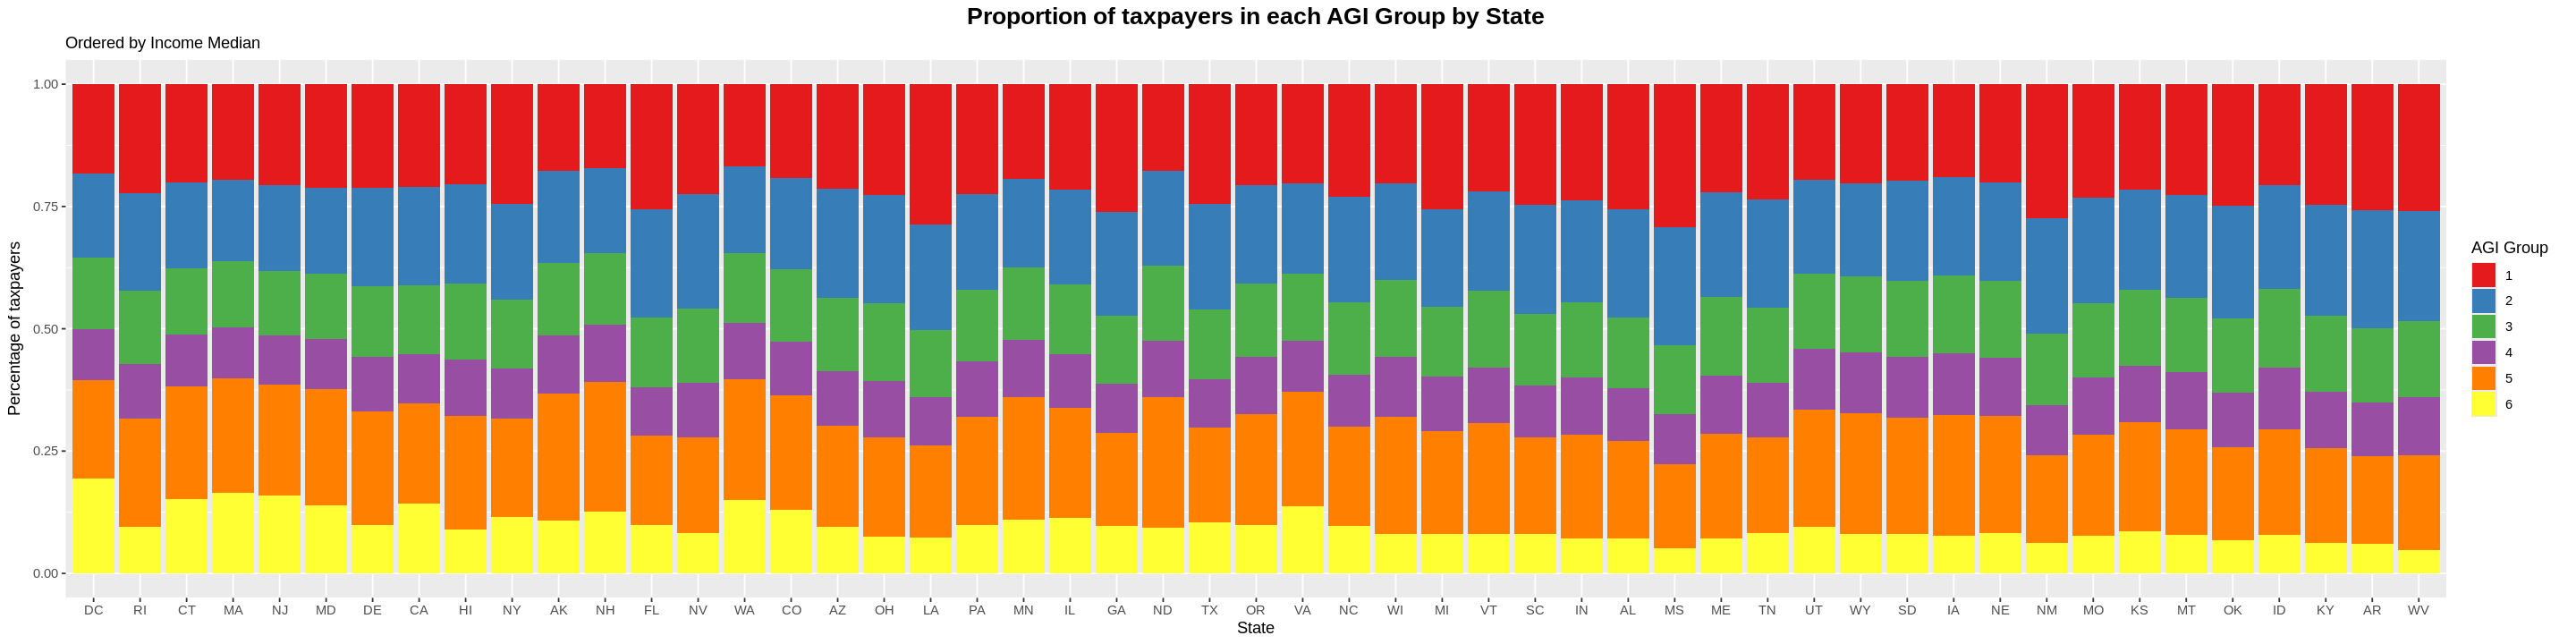

In [136]:
ggplot(aes(x=fct_reorder(STATE, aver_income, .fun = median, .desc = TRUE), weight = num_of_taxpayers, fill=as.factor(agi_stub)), data=income1) + geom_bar(position="fill") +
  labs(fill="AGI Group", x= "State", y="Percentage of taxpayers", title="Proportion of taxpayers in each AGI Group by State", subtitle="Ordered by Income Median") +
  scale_fill_brewer(palette = "Set1") + theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

- The proportion of each AGI Group per state helps explain some of the stats observed in Income per State boxplot above. DC, MA, NJ, WA and CT have the highest percentage of taxpayers in AGI group 6, which is the highest income bracket.
- Surprisngly, NJ has a higher percentage of taxpayers in group 5 and 6 compared to NY, which explains why NJ has higher average income and median income.
- Florida has a fairly high average income compared to the entire country; however, based on this distribution graph, FL has an average percentage of taxpayers in group 5 and 6, and a fairly large portion of taxpayers in group 1 and 2. As noticed in the Distribution of Income by State boxplot, Florida has the highest outliers in Average Income. It is possible that even though FL doesn't have a lot of taxpayers in high AGI groups, a few extremely wealthy individuals in FL have boosted the state average income.

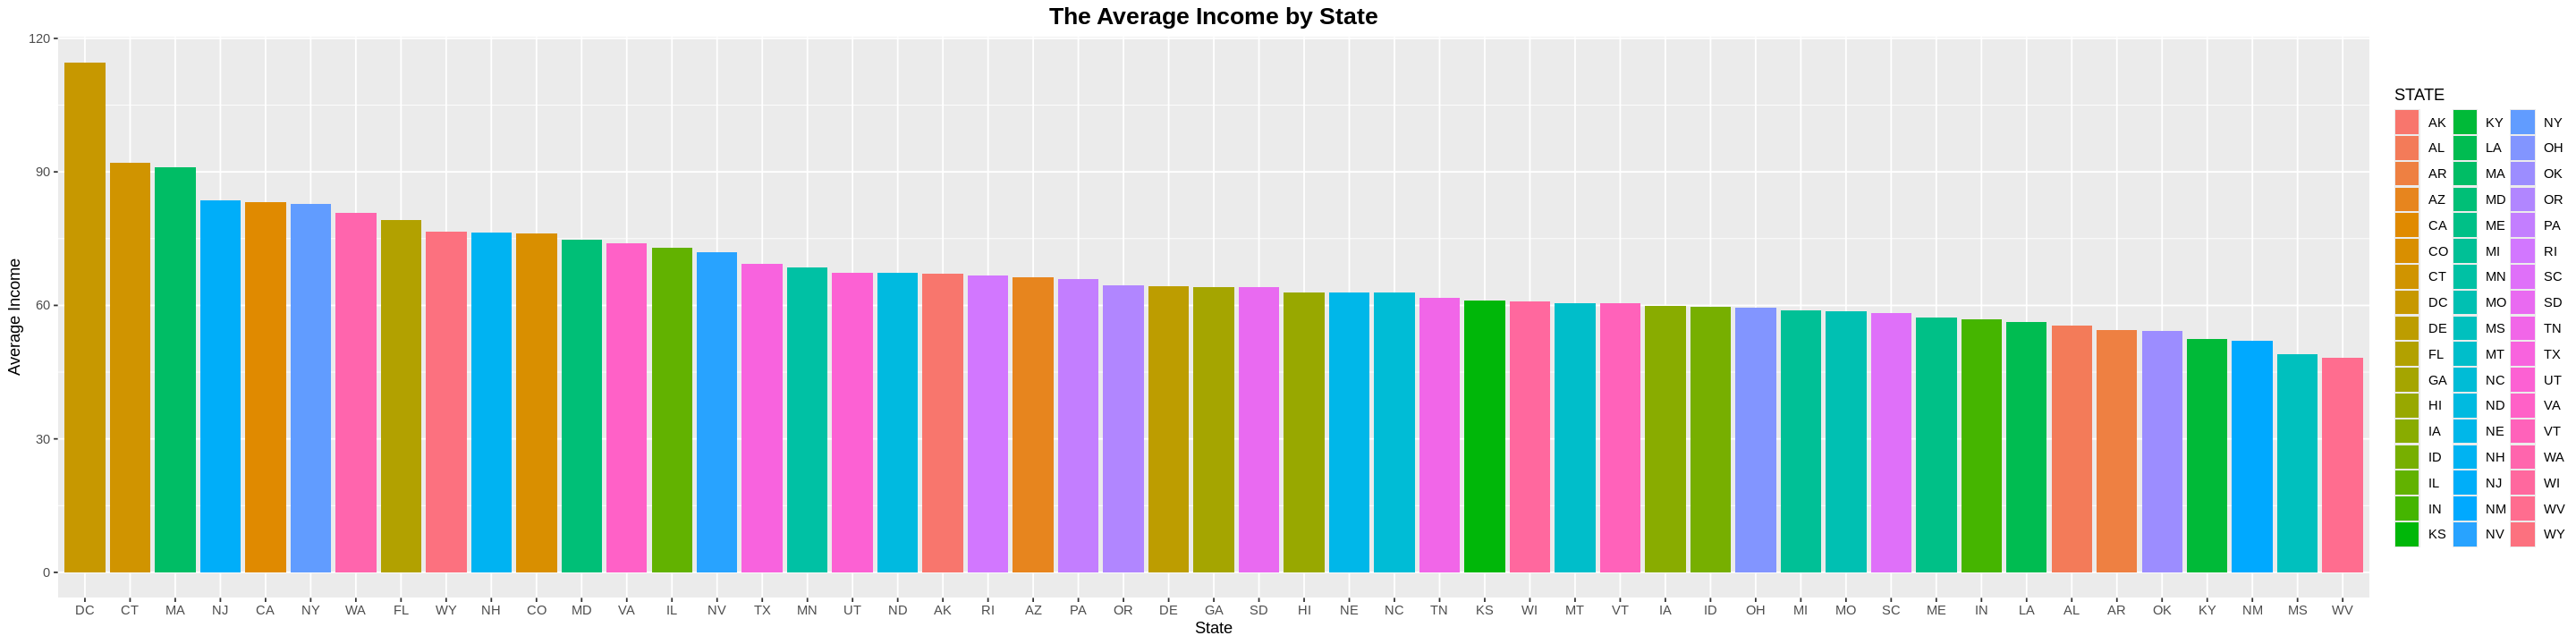

In [137]:
ggplot(state_average1, aes(x=fct_reorder(STATE, income, .desc = TRUE), y=income, fill=STATE)) +
  geom_col() +  scale_color_brewer() +
  labs(x="State", y="Average Income", title="The Average Income by State") +  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

- Looking at the average income per taxpayer (calculated in the *state_average1* dataframe), DC, Connecticut and Massachusetts had the highest average income while West Virginia and Mississippi had the lowest income reported in 2022.
- DC and MA have consistently ranked top in Income stats (both median and average). CT, NJ, CA, NY, WA and FL also have very high Income average compared to the rest of the country. It also shows in the heat map below based on the darker color of the states.
- Even though RI had a high Income median as shown in the boxplot, its average Income lies around the middle rank. It is possible that on average, taxpayers in RI have a fair distribution of wealth among each other, while the other states such as CT, NJ, CA and WA have more outliers of wealthy individuals.
- One state that stood out to have a fairly high average income despite not having a strong economic state is Wyoming. Even when looking at the proportion of different AGI groups in WY, the percentage of AGI group 6 doesn't seem to be higher than most states.

**The US heat map for average income, based on 2022 tax filing**

Retrieving data for the year 2024



  |======================================================================| 100%


Warning message:
“st_centroid assumes attributes are constant over geometries”


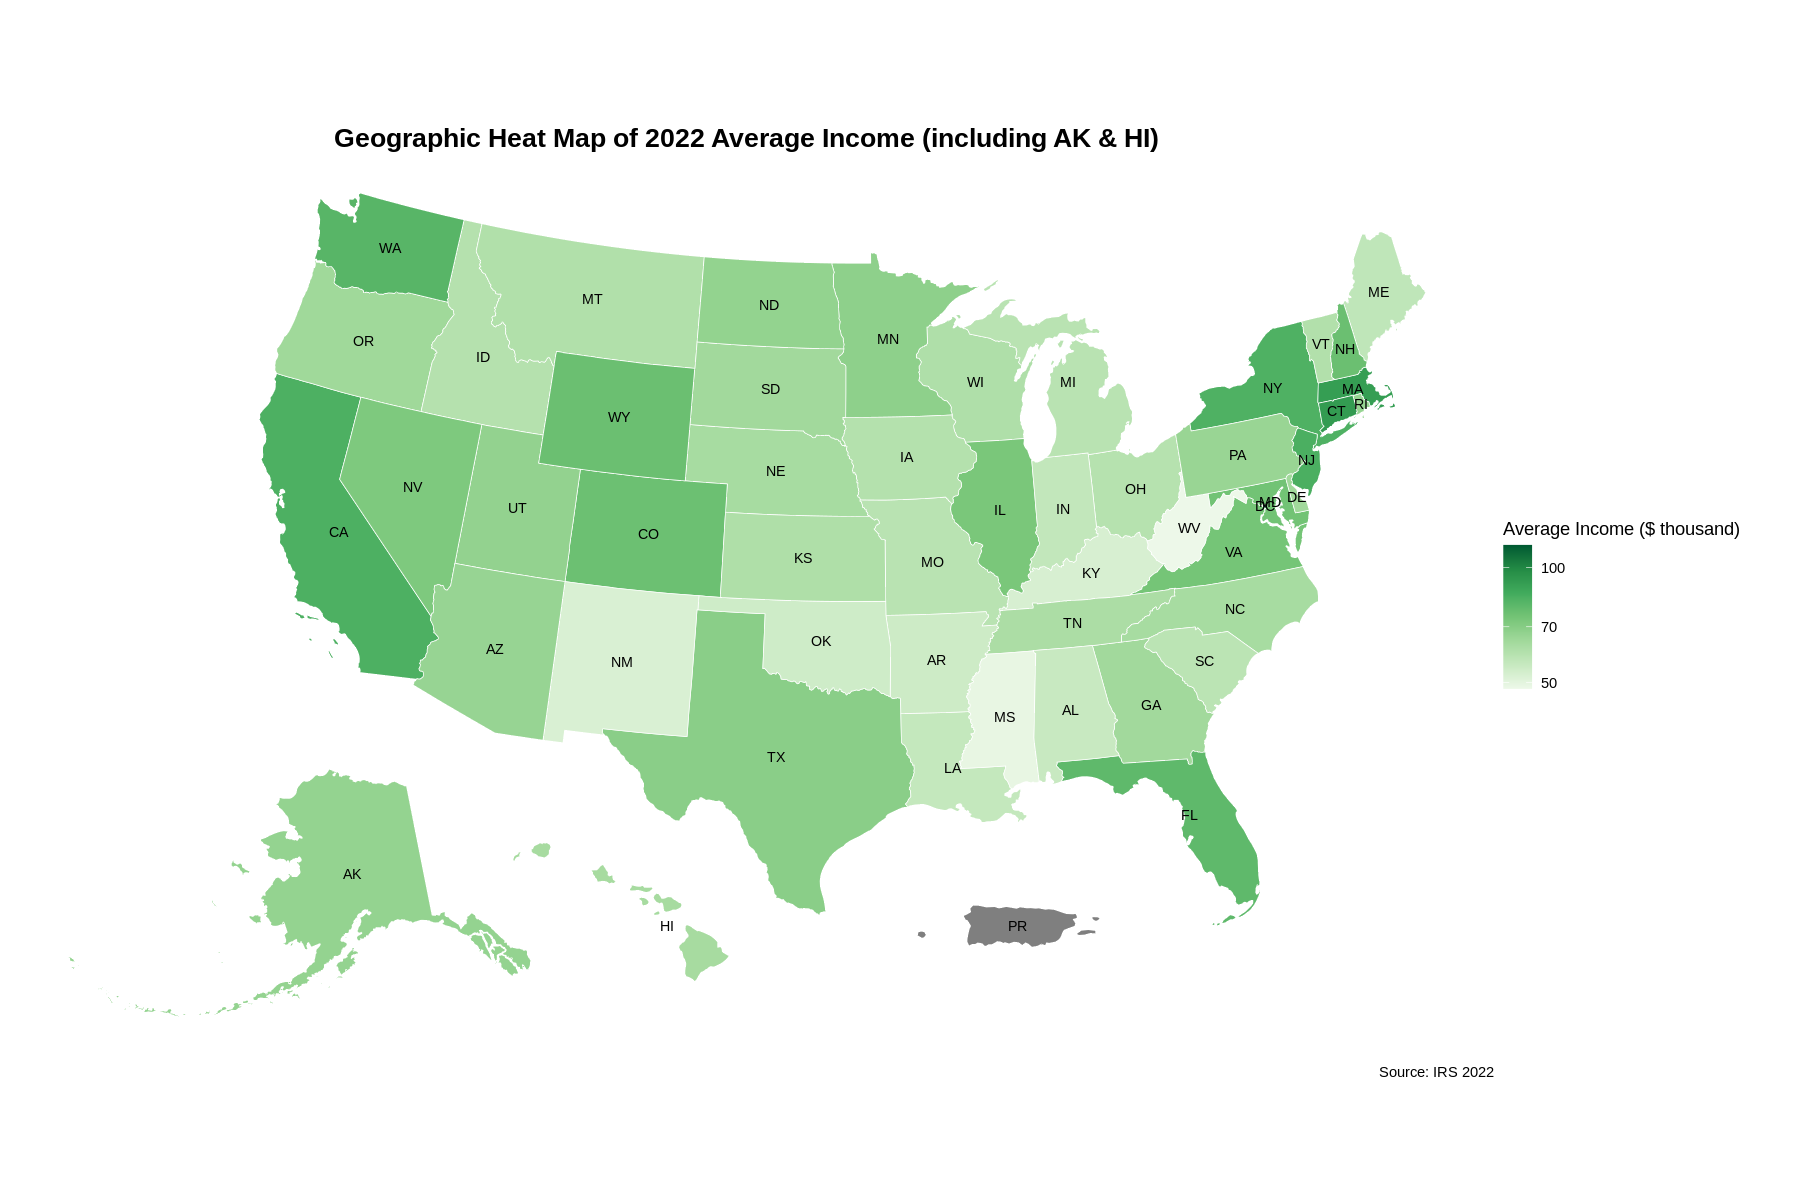

In [138]:
us_geo <- states(cb = TRUE, resolution = "20m") %>%
  shift_geometry()
state_average_clean <- state_average1 %>%
  mutate(STUSPS = STATE)
map_data_final <- us_geo %>%
  left_join(state_average_clean, by = "STUSPS")
state_centroids <- st_centroid(us_geo)
options(repr.plot.width = 15, repr.plot.height = 10)
ggplot(map_data_final) +
  geom_sf(aes(fill = income), color = "white", size = 0.2) +
  scale_fill_distiller(palette = "Greens", direction = 1, trans = "log10", name = "Average Income ($ thousand)") +
  geom_sf_text(data = state_centroids, aes(label = STUSPS), size = 3, color = "black") +
  labs(title = "Geographic Heat Map of 2022 Average Income (including AK & HI)", caption = "Source: IRS 2022") +
  theme_void() +  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

**Potential reasons for High Income states:**
- DC: High concentration of high-paying policy, legal, and lobbying jobs.
- MA: Strong biotech, finance, and education sectors; high-wage Boston metro area.
- CT: Financial services and hedge funds, particularly in Fairfield County (near NYC).
- NJ: High-earning commuters to NYC and Philadelphia; strong pharma/finance presence.
- NY: Wall Street salaries and bonuses drive up the average, despite a large population diversity.
- WA: Major tech hubs (Amazon, Microsoft) and no state income tax on wages attracts high earners.
- CA: Silicon Valley tech salaries and significant capital gains from stock options.
- WY: the zero-tax trinity (Income Tax, Capital Gain Tax and Corporate Gift Tax), extreme privacy for LLC ownership and asset protection (in trust and LLCs). These advantages could attract wealthy individuals.

### B. Federal Tax Distribution

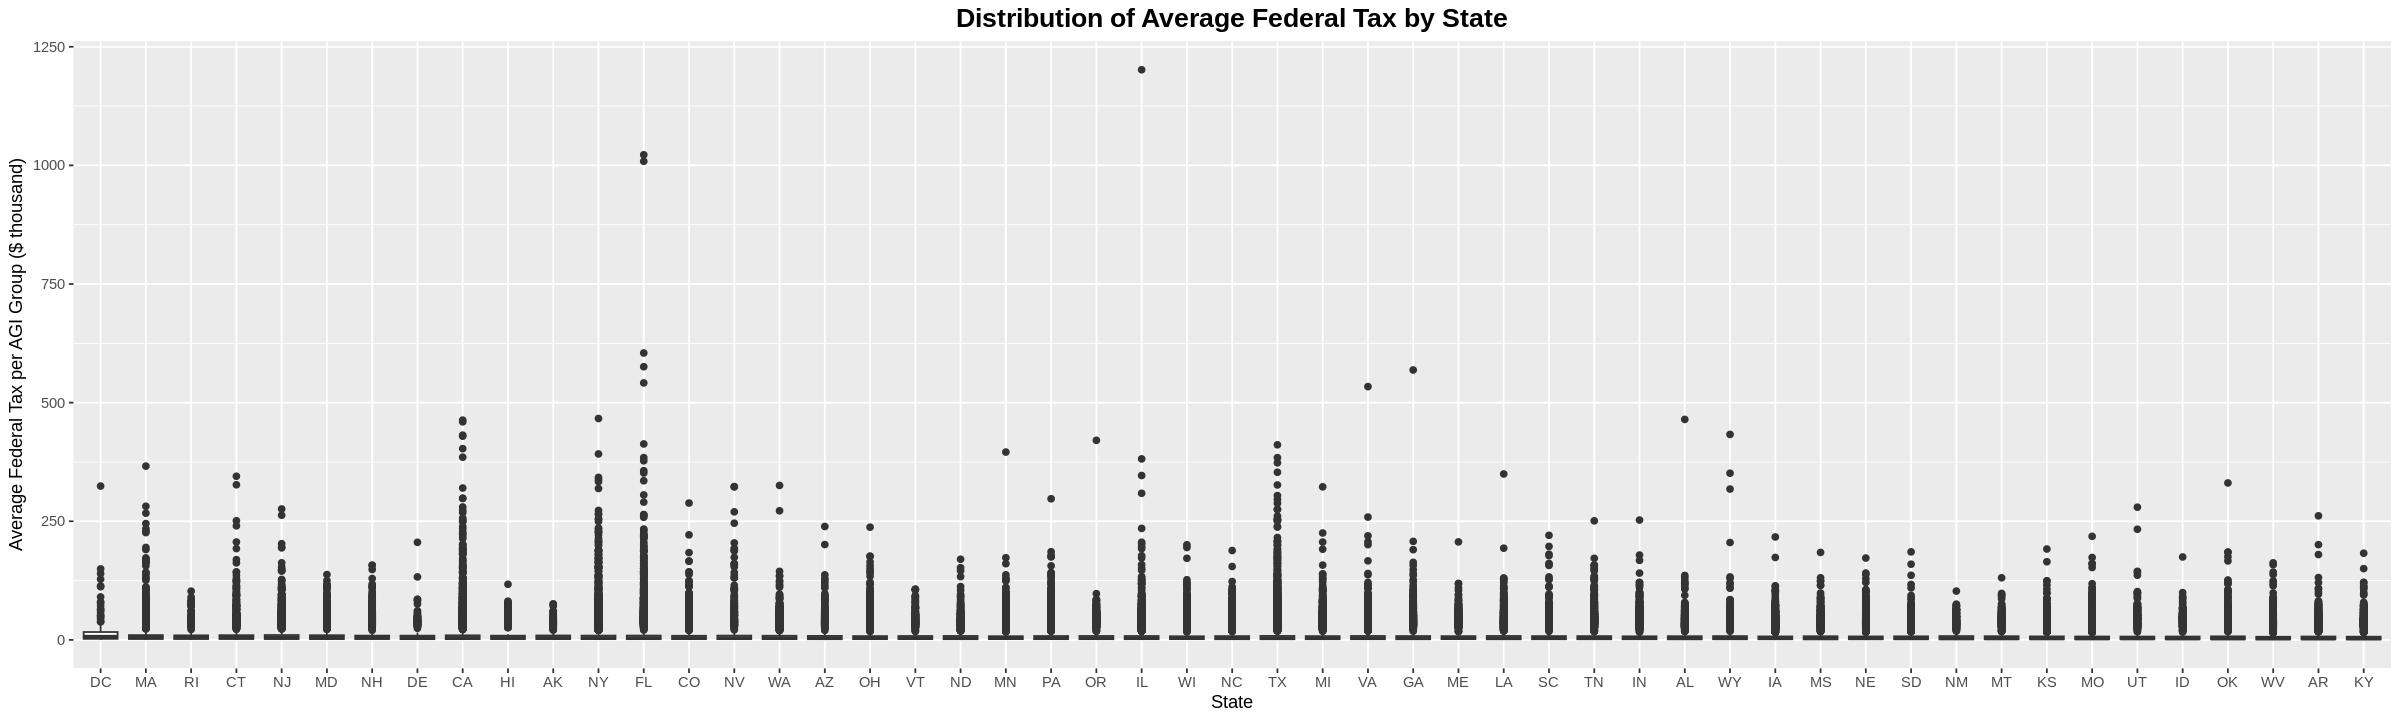

In [139]:
options(repr.plot.width = 20, repr.plot.height = 6)
income1 %>%
  ggplot(aes(x=fct_reorder(STATE, aver_fed_tax, .fun = median, .desc = TRUE), y = aver_fed_tax)) + geom_boxplot() + labs(x="State", y="Average Federal Tax per AGI Group ($ thousand)", title="Distribution of Average Federal Tax by State") +
   theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

- Looking at the distribution of Federal Tax amount per AGI group, there are a lot of outliers on the high end. The state of Illinois has the highest average federal tax of around \$1.2M, followed by Florida (>\$1M) and then Georgia and Virginia (>$500k).
- These outliers in federal tax distribution follow the similar pattern of outliers in Income distribution.

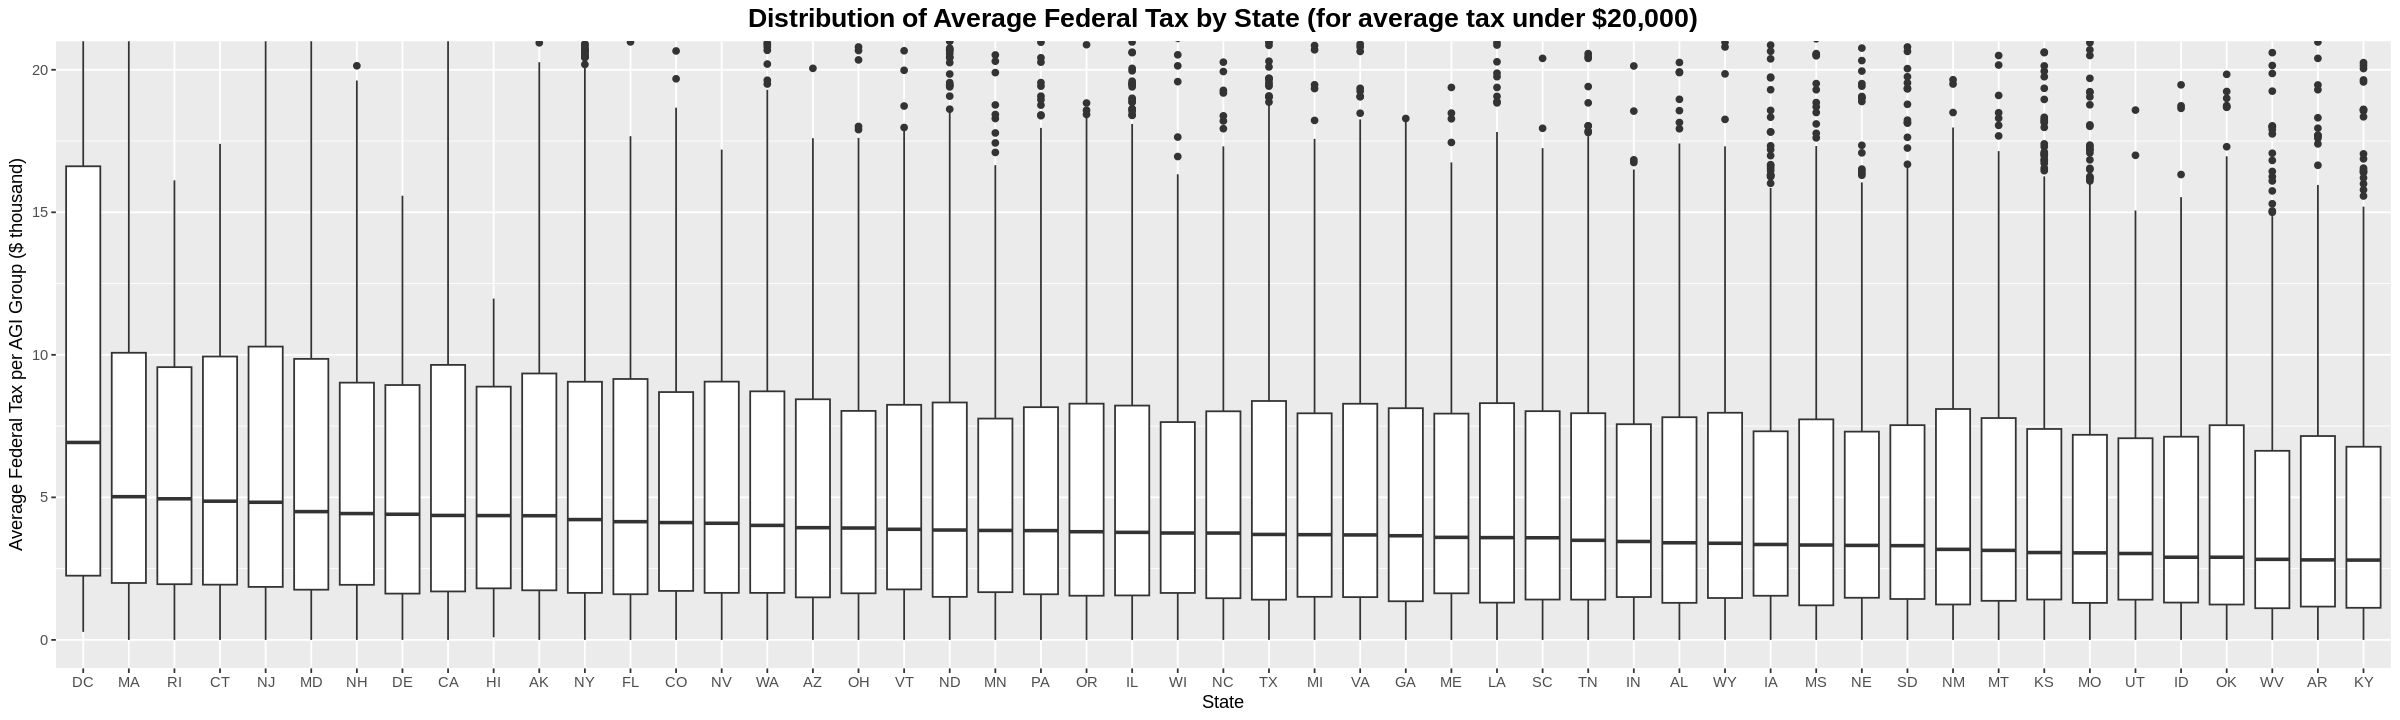

In [141]:
income1 %>%
  ggplot(aes(x=fct_reorder(STATE, aver_fed_tax, .fun = median, .desc = TRUE), y = aver_fed_tax)) + geom_boxplot() +
  labs(x="State", y="Average Federal Tax per AGI Group ($ thousand)", title="Distribution of Average Federal Tax by State (for average tax under $20,000)") +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold")) +
  coord_cartesian(ylim = c(0, 20))

- When capping average federal tax at $20,000, DC has the highest median tax (>\$5k), followed by Massachutsetts, Rhode Island and Connecticut. Kentucky has the lowest federal tax median, followed by Arizona and West Virginia.

### C. Income Portfolio

In [142]:
state_average_long <- state_average1 %>%
  select(STATE, salary_percent, investment_percent, business_percent, retirement_percent, unemployment_percent) %>%
  pivot_longer(cols = c(salary_percent, investment_percent, business_percent, retirement_percent, unemployment_percent),names_to = "income_source", values_to = "percentage") %>%
  mutate(income_source = case_when(
      income_source == "salary_percent" ~ "Salary",
      income_source == "investment_percent" ~ "Investment",
      income_source == "business_percent" ~ "Business",
      income_source == "retirement_percent" ~ "Retirement",
      income_source == "unemployment_percent" ~ "Unemployment",
      TRUE ~ income_source))

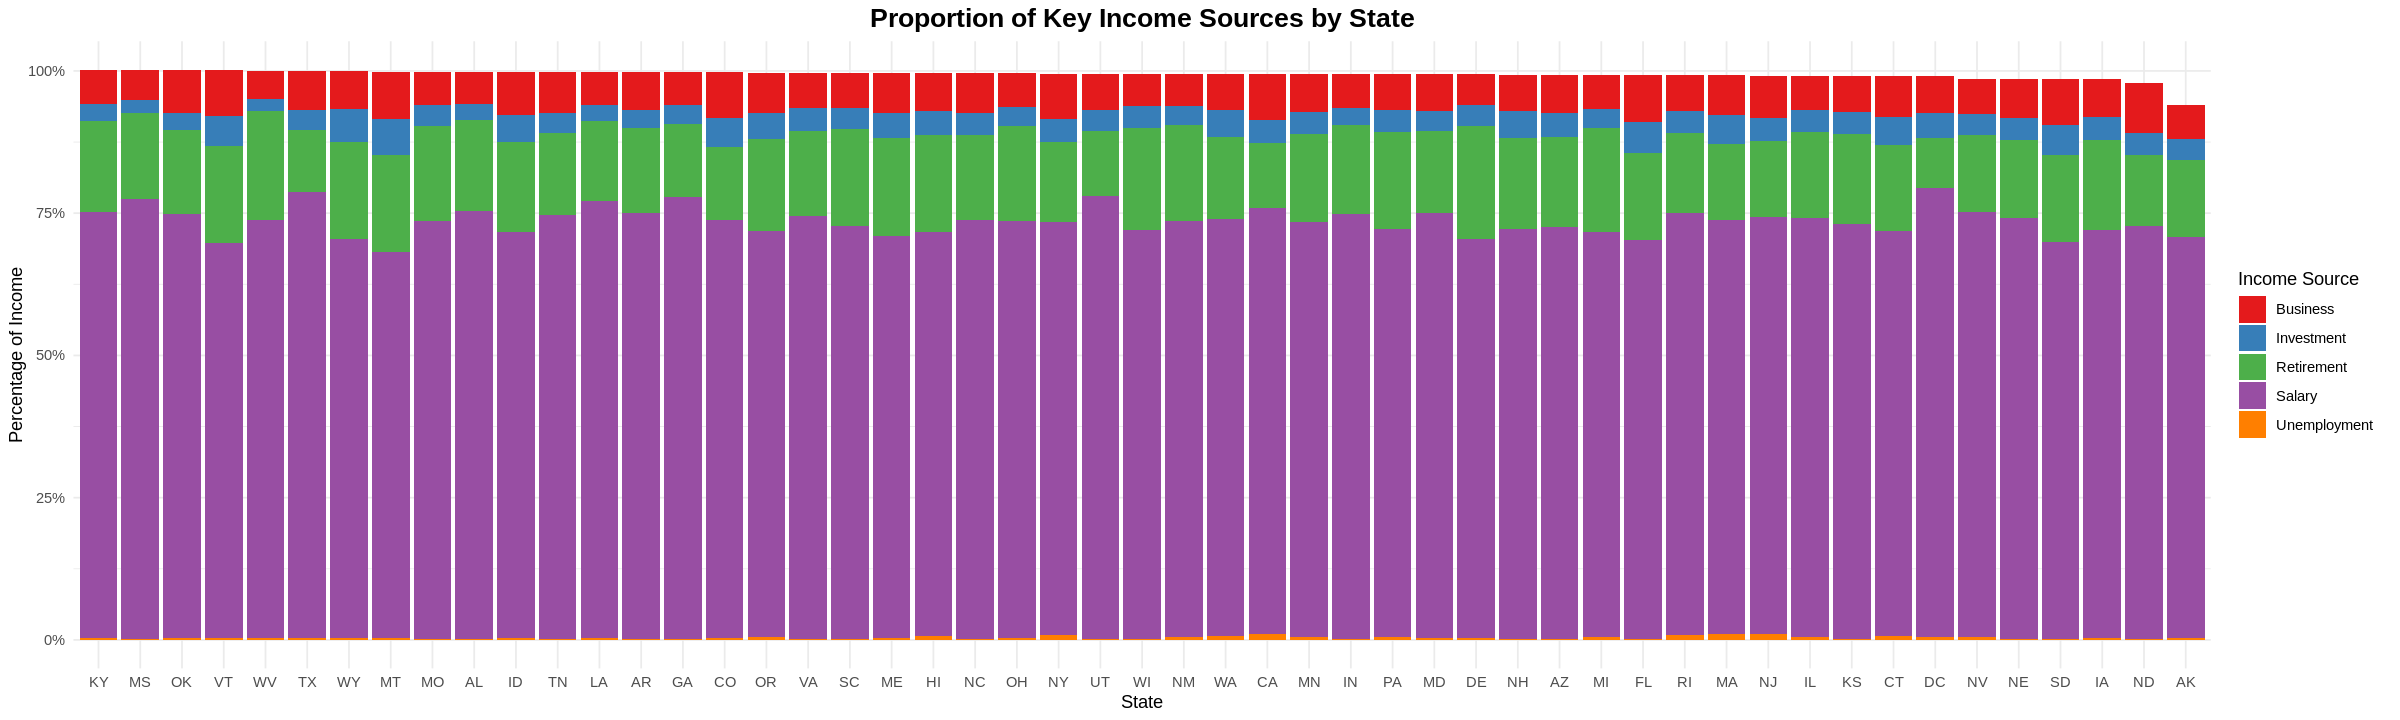

In [143]:
ggplot(state_average_long, aes(x = fct_reorder(STATE, percentage, .fun = sum, .desc = TRUE, .na_rm = TRUE), y = percentage, fill = income_source)) +
  geom_col(position = "stack") +
  labs(title = "Proportion of Key Income Sources by State", x = "State", y = "Percentage of Income",  fill = "Income Source") +
  scale_y_continuous(labels = scales::percent) + scale_fill_brewer(palette = "Set1") +
  theme_minimal() +  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

- Looking at the pverall income portfolio of all states, it's not surprising that salaries/wages contributes to the majority of income across all states, roughly above 75% of total Income.
- Some states with a higher proportion of income coming from salary/wage are: TX, LA, UT and DC.

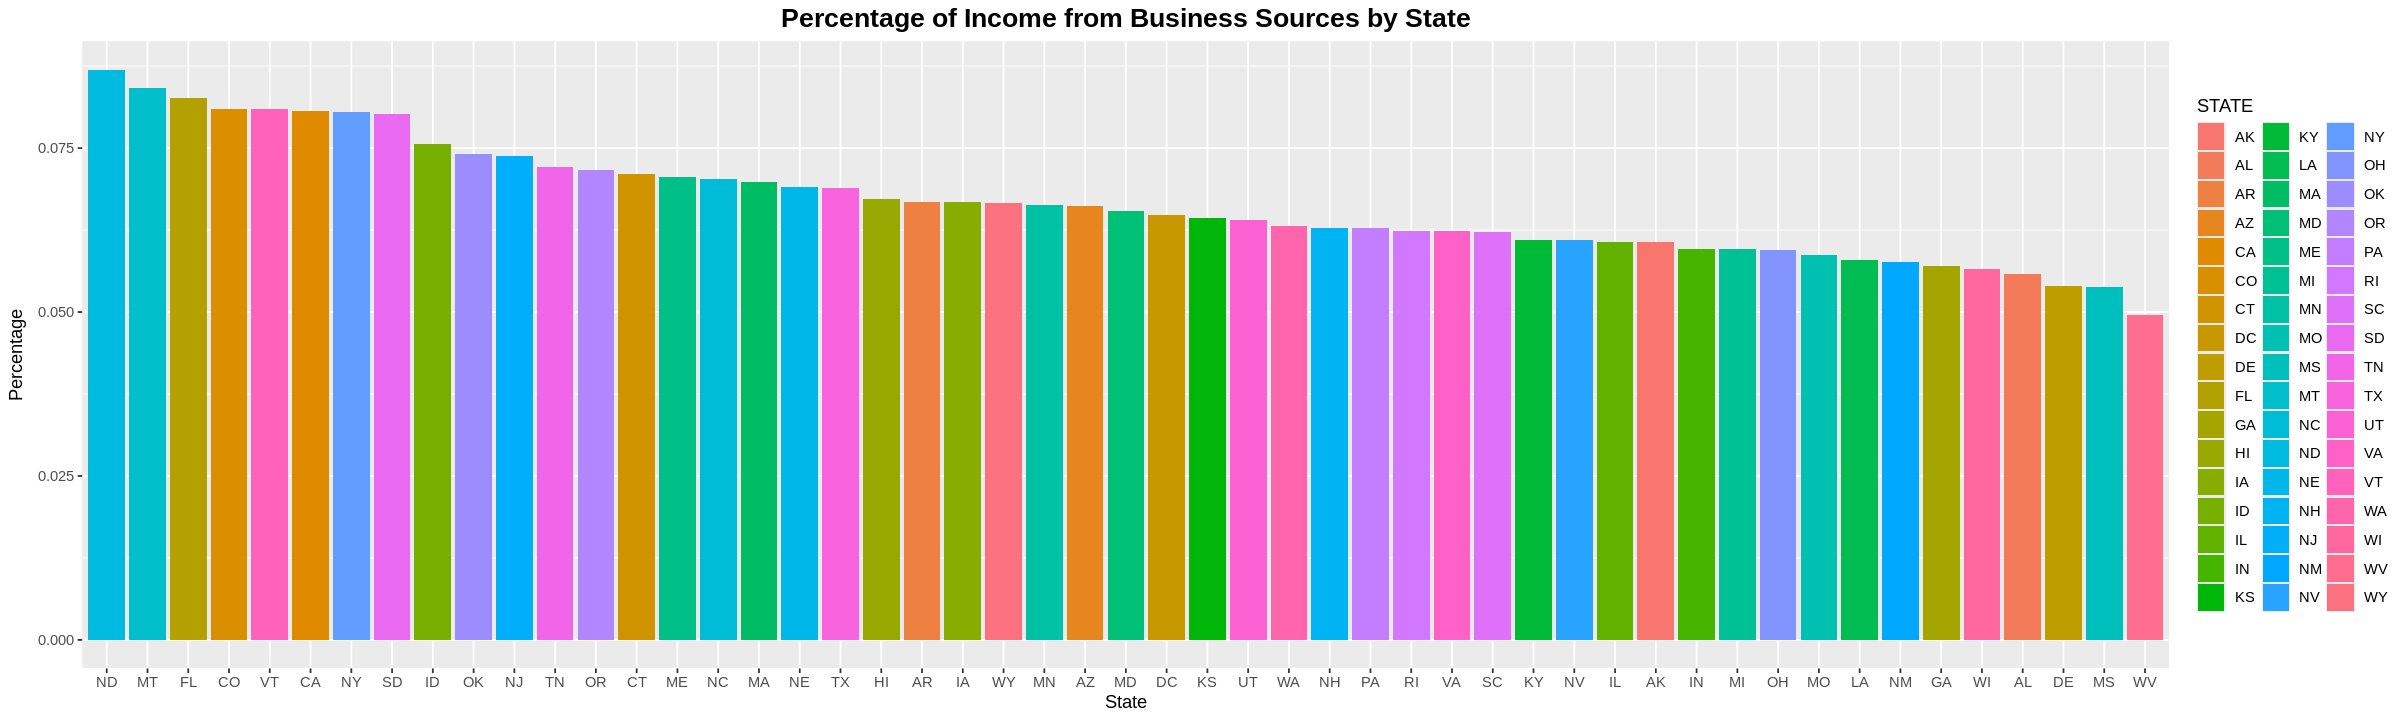

In [144]:
ggplot(aes(x = fct_reorder(STATE, business_percent, .desc = TRUE, .na_rm = TRUE), y=business_percent, fill=STATE), data=state_average1) +
  geom_col() + labs(title="Percentage of Income from Business Sources by State", x="State", y="Percentage") + theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

- North Dakota, Montana and Florida have the highest percentage of Income coming from Business Sources (\~8%), while West Virginia, Mississsippi and Delaware have the lowest (~5%)

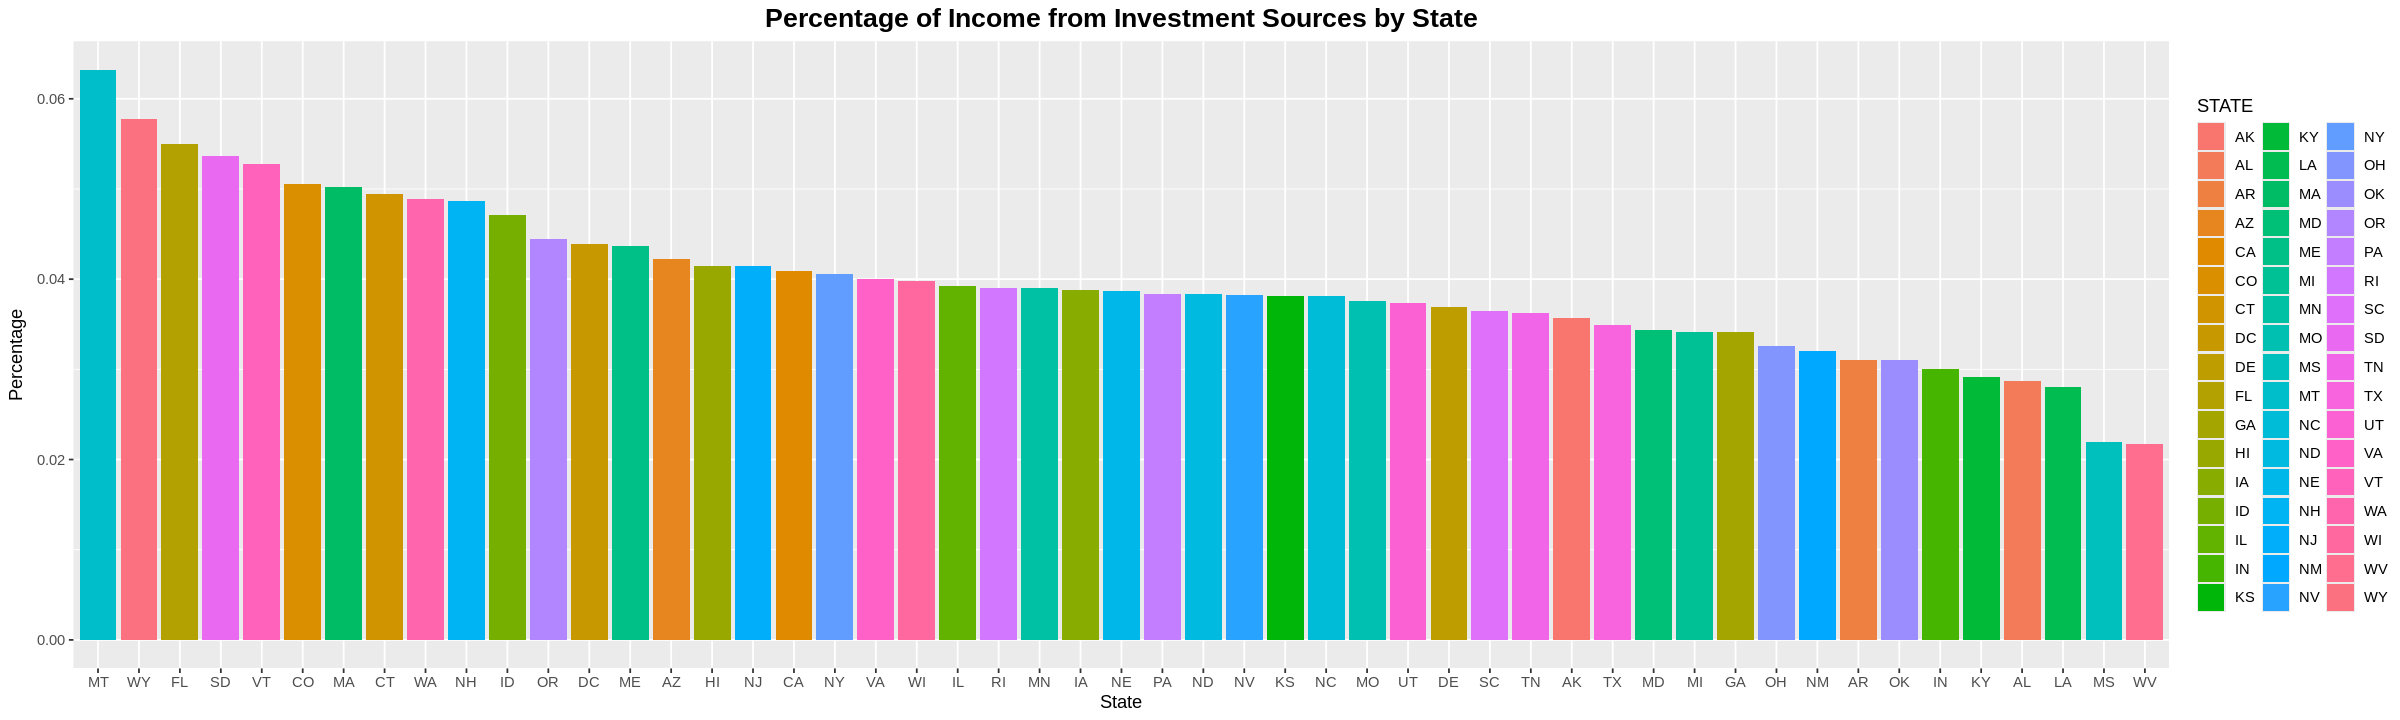

In [145]:
ggplot(aes(x = fct_reorder(STATE, investment_percent, .desc = TRUE, .na_rm = TRUE), y=investment_percent, fill=STATE), data=state_average1) +
  geom_col() + labs(title="Percentage of Income from Investment Sources by State", x="State", y="Percentage") + theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

- Montana, Wyoming and Florida have the highest percentage of Income coming from Investment Sources (>5.5%), while West Virginia and Mississsippi have the lowest (~2%)

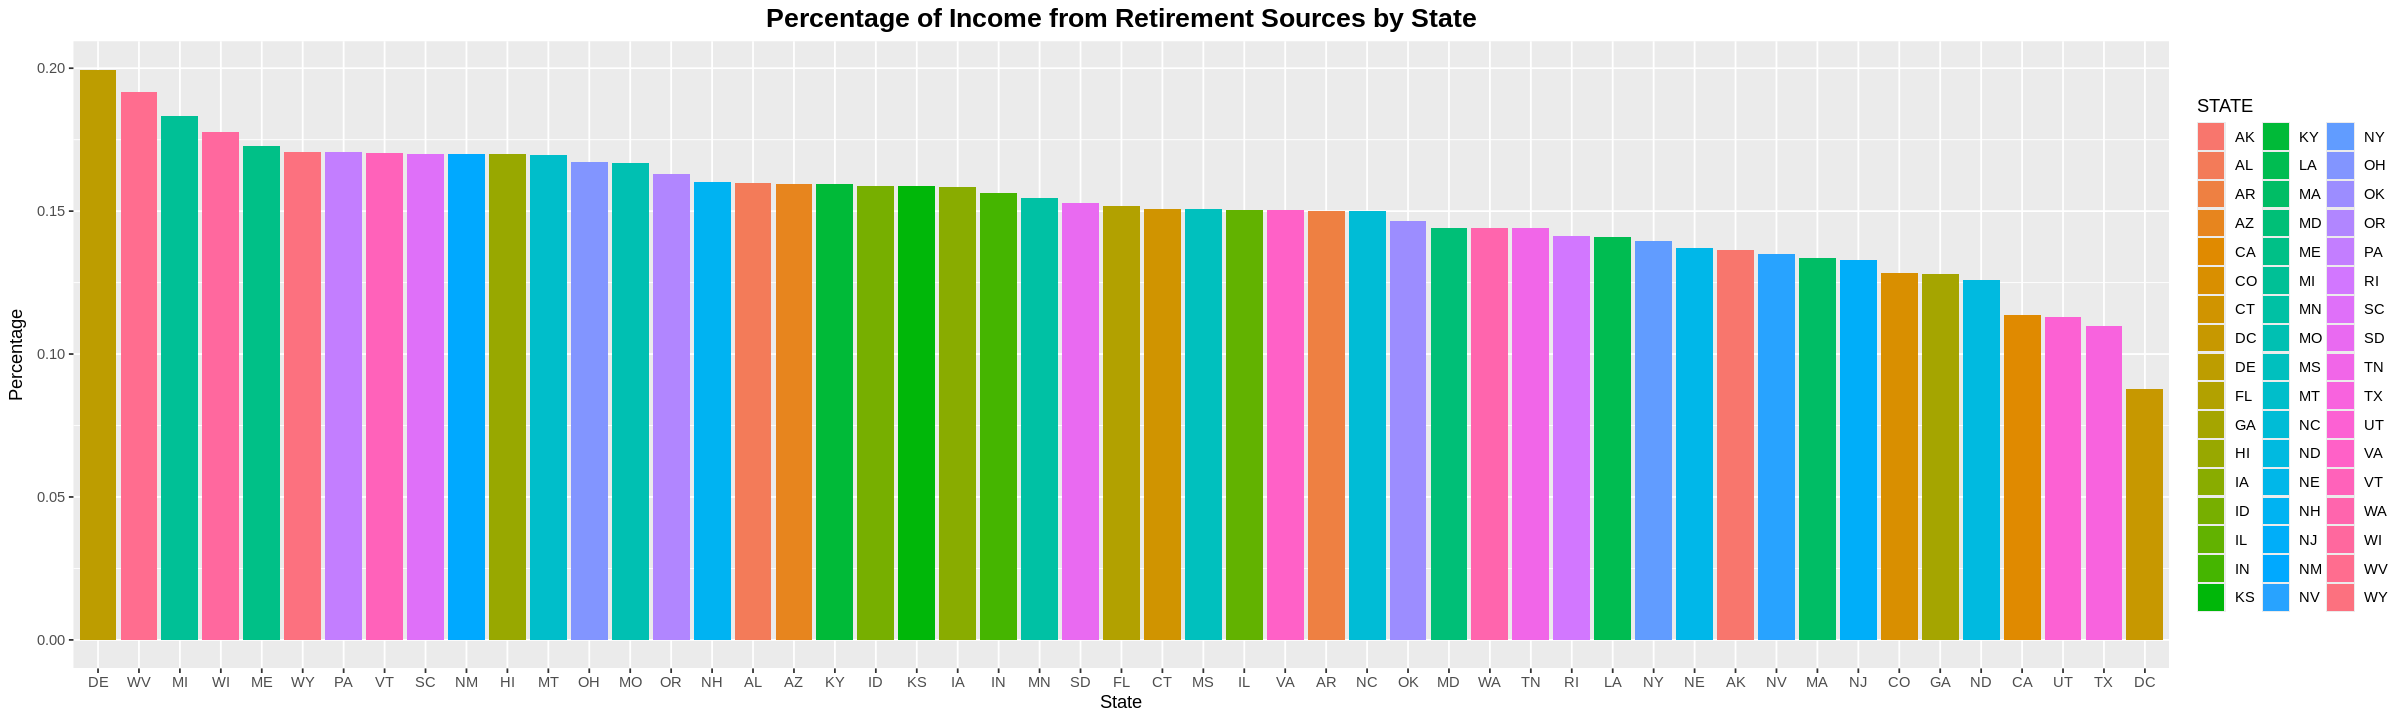

In [146]:
ggplot(aes(x = fct_reorder(STATE, retirement_percent, .desc = TRUE, .na_rm = TRUE), y=retirement_percent, fill=STATE), data=state_average1) +
  geom_col() + labs(title="Percentage of Income from Retirement Sources by State", x="State", y="Percentage") + theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

- Delaware, West Virginia and Michigan have the highest percentage of Income coming from Retirement Sources (>17%), while DC and Texas have the lowest (~10%).
- I have originally thought that Florida ould be in the top of this list due to it beng a top destination for retirees. However, due to its fast-growing economy, the salary/wage portion of income still heavily domiate the total Income portfolio.
- Delaware, West Virginia and Michigan potentially have a high percentage of retirees depending on Pensions and Social Sercurity.

### D. Insights

1. Based on 2022 tax filing, the states that consistently have the highest Income compared to the rest of the country are: DC, Connecticut, Massachusetts and New Jersey (based on both median and average). If a brand or company want to target customers on a state scale based on high income status, these are the top states to focus on.

2. Rhode Island, despite not ranking top based on average Income per State, has an evenly distributed wealth that is high across the entire state. RI should also be in consideration as a target of high income individuals.

3. Florida, California, Washington and New York stand out with a high income average compared to the rest of the country, possibly due to the outliers of high income individuals. This may also signal a big income gap between the top 1% earners and the bottom 50% of the population. Due to the size of these states population, they could also be a great market to target high earners.

4. DC, MA, RI, CT and NJ rank top based on the distribution of Federal Tax liability for the year 2022. It is likely that high earners in these states would like to reduce their tax liablity. Companies that specialize in Estate Planning, Retirement Planning or even Charities could focus on these states with products that would legally reduce tax liablity.

5. ND, MT, FL and CO have a high percentage of Income coming from Business Ownership, Partnership or Passive Income (rental). These states could be a great focus for Small Business Services focusing on accounting, legal, HR or IT.

6. MT, WY, FL and SD have a high percentage of Income coming from Investment sources; while DE, WV and MI hve a high portion of Income coming from Retirement sources (especially pension). Small or local investment firms and Retirement planning services could focus on these states that may be ignored by big investment banks.


## **V. Economic and Wealth Distribution by ZIP Code**

In [147]:
zip_average1 %>%
  arrange(desc(income)) %>%
  head()

zipcode,STATE,number_of_taxpayers,income,agi,fed_tax,taxable_income,salary,salary_percent,investment_percent,business_percent,retirement_percent,unemployment_percent,total_percent
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
33109,FL,610,2895.925,2887.657,755.4443,2616.0213,362.1148,0.2712546,0.6291758,0.13701468,0.01342847,0.0000000000,1.0508736
33480,FL,8900,2207.103,2200.659,550.3931,2008.0053,176.0520,0.2160539,0.5554811,0.08382359,0.13761766,0.0020999719,0.9950762
94301,CA,11380,1166.592,1162.376,237.6269,880.0682,234.1969,0.3848648,0.3035913,0.07397738,0.08339315,0.0030910188,0.8489177
34102,FL,7990,1153.543,1147.211,289.8965,1028.8456,183.8372,0.3042721,0.3750070,0.17707731,0.13154419,0.0005106060,0.9884112
94304,CA,2710,1149.632,1147.946,208.3974,820.2347,133.3996,0.4315848,0.4906203,0.02832201,0.06950277,0.0006007587,1.0206306
94027,CA,4540,1074.820,1066.504,297.8139,981.4656,380.7615,0.4236516,0.3699650,0.12978194,0.06730477,0.0015670068,0.9922704


### A. Heat Map of Income by ZIP Code

In [148]:
# Get ZCTA (ZIP Code Tabulation Areas) geographic data for the entire US
# Using year = 2020 as 2022 is not yet available, and cb = TRUE for simpler boundaries
options(tigris_use_cache = TRUE)
zips_sf <- zctas(cb = TRUE, year = 2020, starts_with = c("0", "1", "2", "3", "4", "5", "6", "7", "8", "9")) %>%
  shift_geometry() # Apply shift_geometry to reposition AK and HI

# Filter out non-numeric ZIP codes from zip_average1 to ensure clean merge
zip_average1_numeric_zip <- zip_average1 %>%
  filter(!is.na(as.numeric(zipcode)))

# Merge the ZCTA spatial data with zip_average1 data
# Rename the 'GEOID' column in zips_sf to 'zipcode' for proper merging

# Ensure zipcode is character type in both for proper merging
zip_average1_numeric_zip$zipcode <- as.character(zip_average1_numeric_zip$zipcode)
zips_sf$GEOID <- as.character(zips_sf$GEOID)

income_zip_map_data <- zips_sf %>%
  left_join(zip_average1_numeric_zip, by = c("GEOID" = "zipcode"))

# Filter out NA incomes (ZIP codes that don't have income data in our dataset)
income_zip_map_data_filtered <- income_zip_map_data %>%
  filter(!is.na(income))

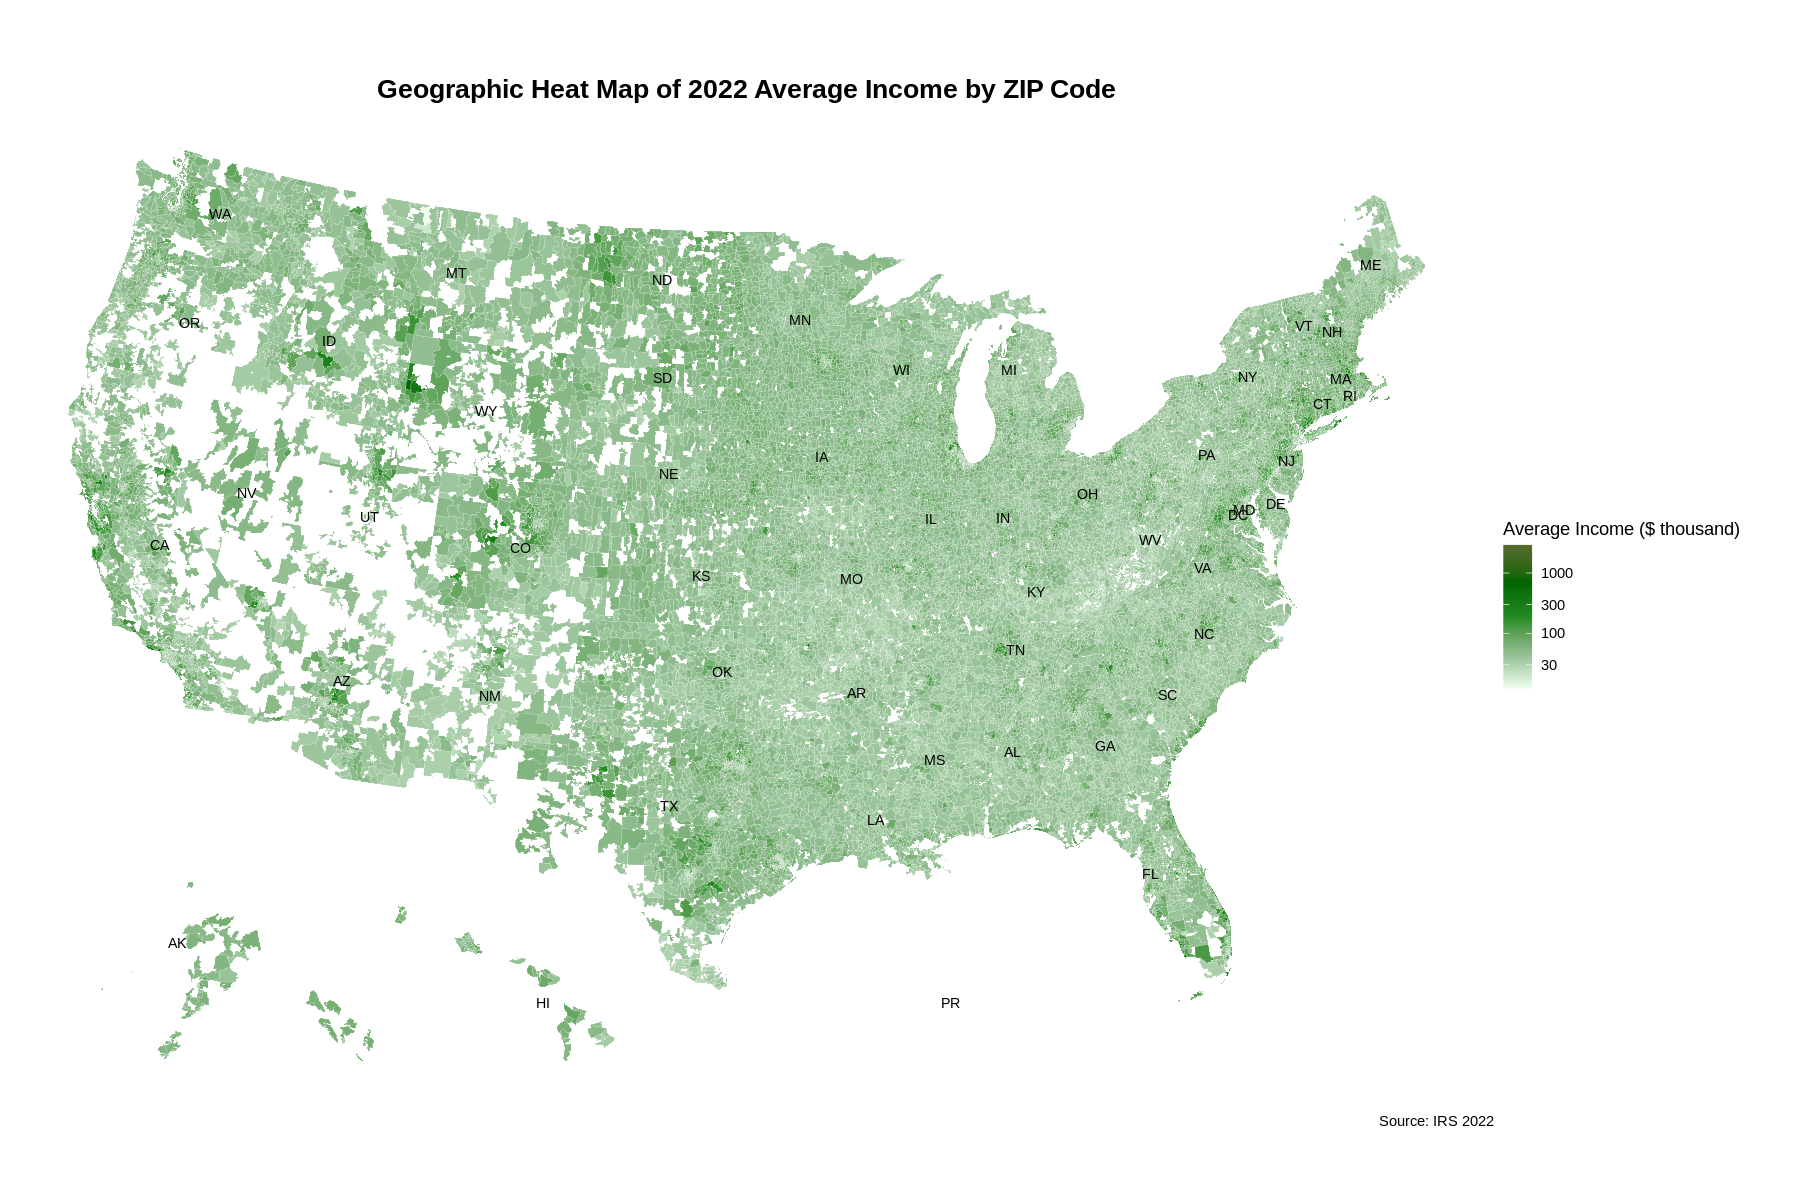

In [149]:
options(repr.plot.width = 15, repr.plot.height = 10)
ggplot(income_zip_map_data_filtered) +
  geom_sf(aes(fill = income), color = "white", size = 0.05) +
  scale_fill_gradientn(colors = c("honeydew", "darkseagreen", "forestgreen", "darkgreen", "darkolivegreen"),
                       trans = "log10",
                       name = "Average Income ($ thousand)") +
  geom_sf_text(data = state_centroids, aes(label = STUSPS), size = 3, color = "black") +
  labs(title = "Geographic Heat Map of 2022 Average Income by ZIP Code", caption = "Source: IRS 2022") +
  theme_void() +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

- Based on the heat map, we can see that each state has some areas with high income (darker color), potentially the big cities or metropolis.
- TX, FL, CA, CO and WY seem to have some ZIP codes with very high earning (dark green), standing out among the rest of their state (ligher color).
- The north east region by the coast, including MA, RI, CT, NJ and DC, stands out with saturated darker color.

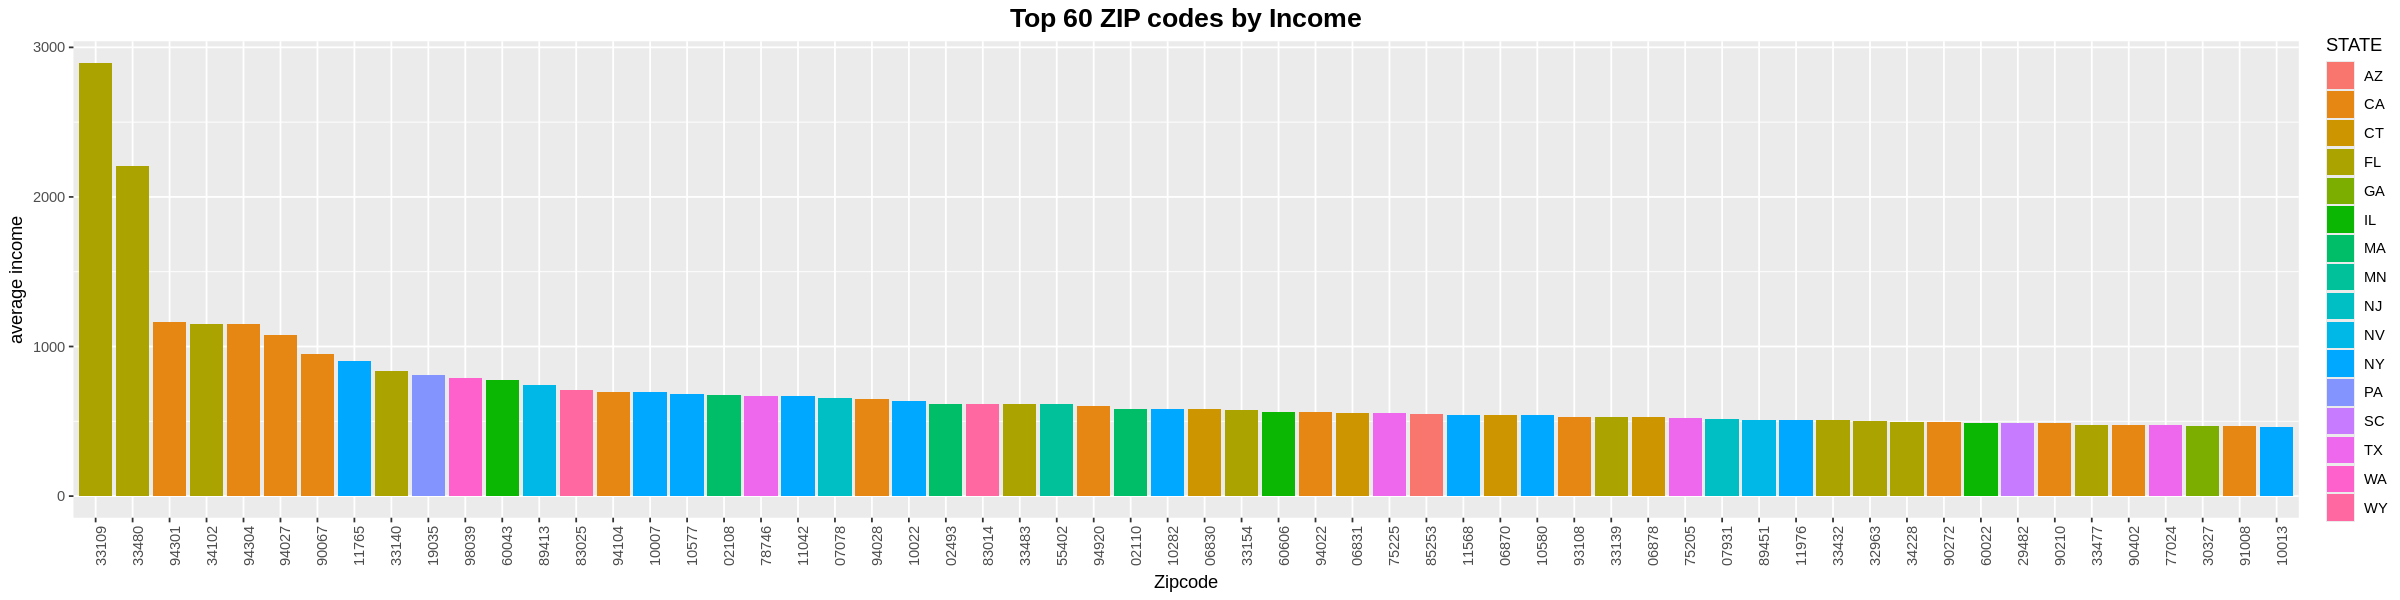

In [150]:
options(repr.plot.width = 20, repr.plot.height = 5)
zip_average1 %>%
  arrange(desc(income)) %>%
  head(60) %>%
  ggplot(aes(x=fct_reorder(zipcode, income, .desc = TRUE, .na_rm = TRUE), y=income, fill=STATE)) + geom_col() +
  labs(x="Zipcode", y="average income", title = "Top 60 ZIP codes by Income") +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold")) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

- Florida and California have several ZIP codes that have the highest Income in the country, with FL being dorminant in the top 60 codes.
- At the first look, it seemed strange that 33109 and 33480 have much higher income compared to the rest of the ZIP codes in the top 60. Upon further research, these ZIP codes are well-known ultra-wealthy enclaves that house some billionaires, who are attracted by Florida's zero state income tax.
- California, New Jersey and New York, despite early hypothesis to have more ZIP codes in the top 60 than Florida, seem to have a consistently high Income across the majority of taxpayers. However, on average, their income are lower than Florida due to some extreme outliers of high earners in this state.

### B. Segmentation of Zip Codes based on:

1.   **Income Level**
2.   **Income Portfolio** (Salary, Business, Investment, Retirement and Unemployment)




In [151]:
clustering_data <- zip_average1 %>%
  select(zipcode, income, salary_percent, investment_percent, business_percent, retirement_percent, unemployment_percent) %>%
  # Replace NA values with 0 in the selected percentage columns
  mutate(across(c(income, salary_percent, investment_percent, business_percent, retirement_percent, unemployment_percent), ~replace_na(., 0)))

In [152]:
clustering_data_scaled <- clustering_data %>%
  ungroup() %>%
  select(-zipcode) %>%
  scale()

head(clustering_data_scaled)

income,salary_percent,investment_percent,business_percent,retirement_percent,unemployment_percent
-0.07995545,-0.1727079,-0.3079200,-0.41553560,0.3239797,1.8680749
0.34709608,-0.7306047,1.0300520,0.10800498,0.2207904,0.7664329
-0.10728782,0.1993268,-0.2029326,-0.27356775,-0.1154528,1.8371781
0.07475712,-0.1275160,-0.1174060,-0.14016210,0.2793849,1.0744125
-0.13279129,-0.3916320,-0.1380534,-0.63774858,0.7916373,0.7049916
0.08817419,-0.2903552,-0.1356573,-0.01557638,0.2863220,1.4928508


In [153]:
k_max <- 10
wss <- sapply(1:k_max, function(k){
  kmeans(clustering_data_scaled, centers = k, nstart = 25)$tot.withinss
})
wss_df <- data.frame(k = 1:k_max, wss = wss)

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1379400)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1379400)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1379400)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1379400)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1379400)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1379400)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1379400)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1379400)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1379400)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1379400)”
Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1379400)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 1379

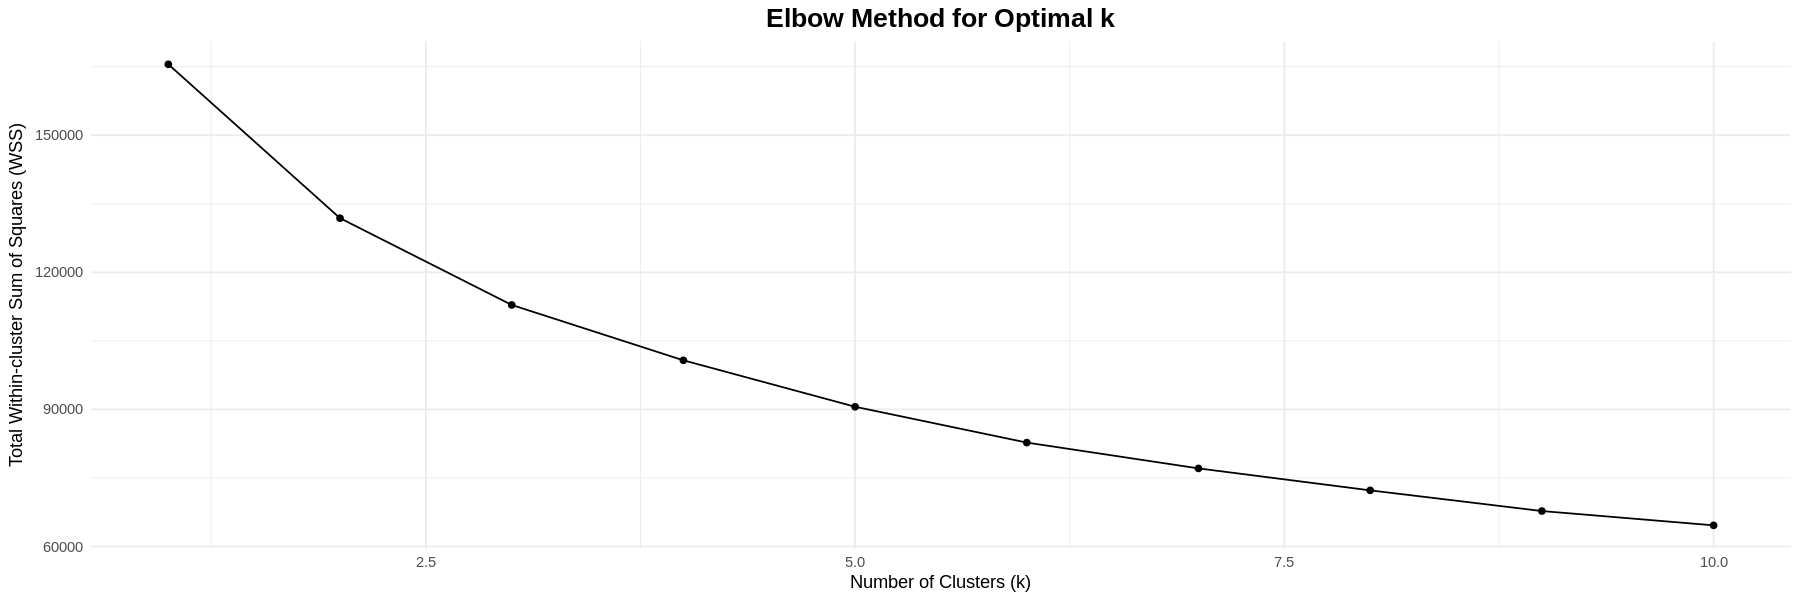

In [154]:
options(repr.plot.width = 15, repr.plot.height = 5)
ggplot(wss_df, aes(x = k, y = wss)) +
  geom_line() +
  geom_point() +
  labs(title = "Elbow Method for Optimal k",
       x = "Number of Clusters (k)",
       y = "Total Within-cluster Sum of Squares (WSS)") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))


In [155]:
optimal_k <- 4 # Based on visual inspection of the elbow plot
kmeans_result <- kmeans(clustering_data_scaled, centers = optimal_k, nstart = 25)

clustering_data_with_clusters <- clustering_data %>%
  ungroup() %>%
  mutate(cluster = kmeans_result$cluster)

In [156]:
cluster_characteristics <- clustering_data_with_clusters %>%
  group_by(cluster) %>%
  summarise(
    size = n(),
    avg_income = mean(income),
    avg_salary_percent = mean(salary_percent),
    avg_investment_percent = mean(investment_percent),
    avg_business_percent = mean(business_percent),
    avg_retirement_percent = mean(retirement_percent),
    avg_unemployment_percent = mean(unemployment_percent),
    num_zipcodes = n()
  ) %>%
  arrange(cluster)

# Display cluster characteristics
print(cluster_characteristics)

# A tibble: 4 × 9
  cluster  size avg_income avg_salary_percent avg_investment_percent
    <int> <int>      <dbl>              <dbl>                  <dbl>
1       1 14953       49.8              0.726                 0.0268
2       2   419      329.               0.523                 0.226 
3       3  6297       51.2              0.810                 0.0188
4       4  5919       77.2              0.610                 0.0675
# ℹ 4 more variables: avg_business_percent <dbl>, avg_retirement_percent <dbl>,
#   avg_unemployment_percent <dbl>, num_zipcodes <int>


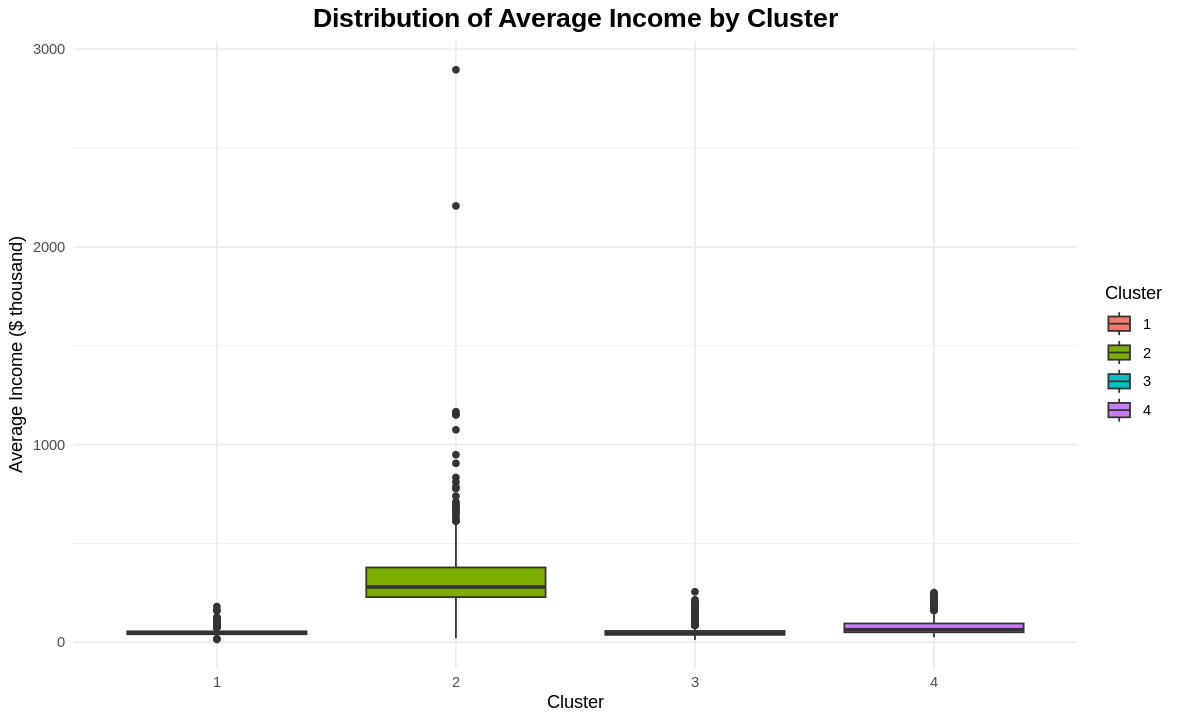

In [157]:
options(repr.plot.width = 10, repr.plot.height = 6)
ggplot(clustering_data_with_clusters, aes(x = as.factor(cluster), y = income, fill = as.factor(cluster))) +
  geom_boxplot() +
  labs(title = "Distribution of Average Income by Cluster",
       x = "Cluster",
       y = "Average Income ($ thousand)",
       fill = "Cluster") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

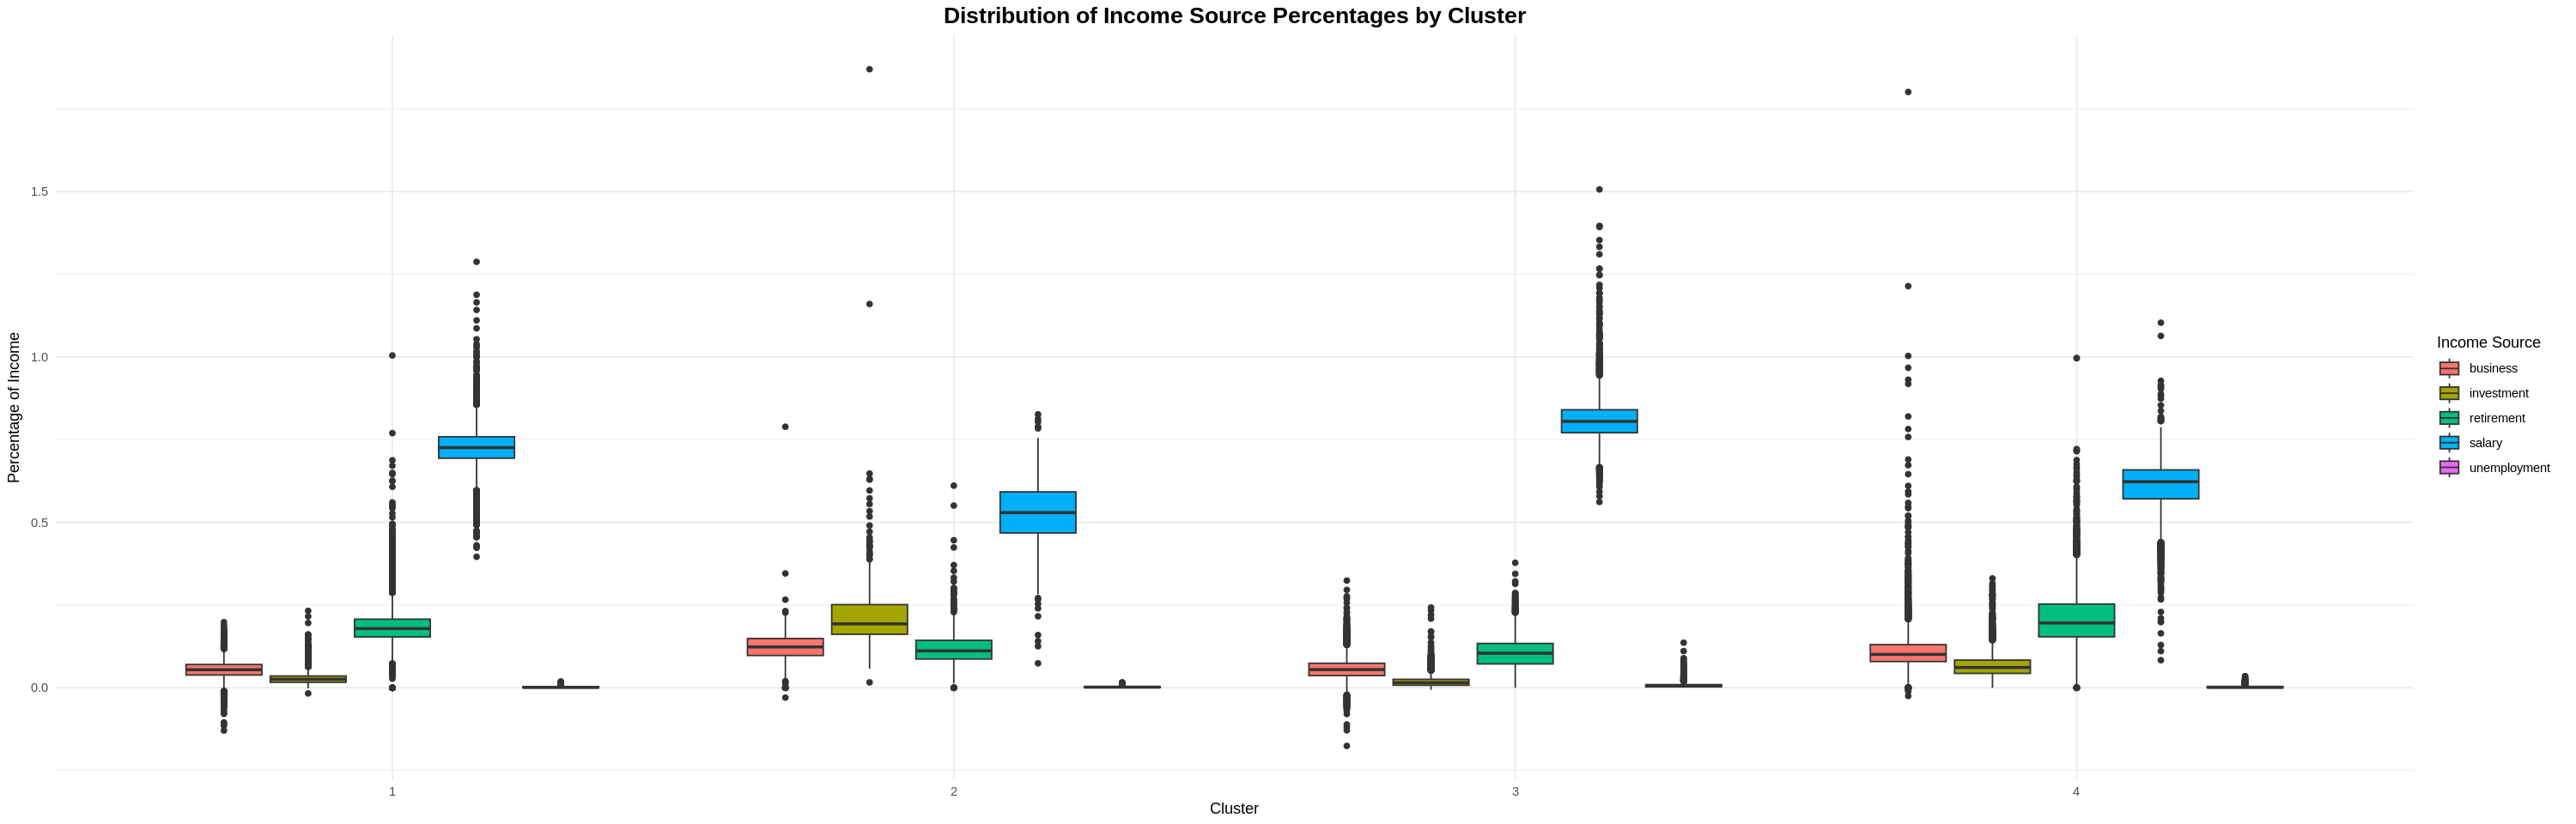

In [158]:
options(repr.plot.width = 25, repr.plot.height = 8)
clustering_data_with_clusters %>%
  select(cluster, salary_percent, investment_percent, business_percent, retirement_percent, unemployment_percent) %>%
  pivot_longer(cols = -cluster, names_to = "income_source", values_to = "percentage") %>%
  mutate(income_source = str_replace(income_source, "_percent", "")) %>%
  ggplot(aes(x = as.factor(cluster), y = percentage, fill = income_source)) +
  geom_boxplot() +
  labs(title = "Distribution of Income Source Percentages by Cluster",
       x = "Cluster",
       y = "Percentage of Income",
       fill = "Income Source") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

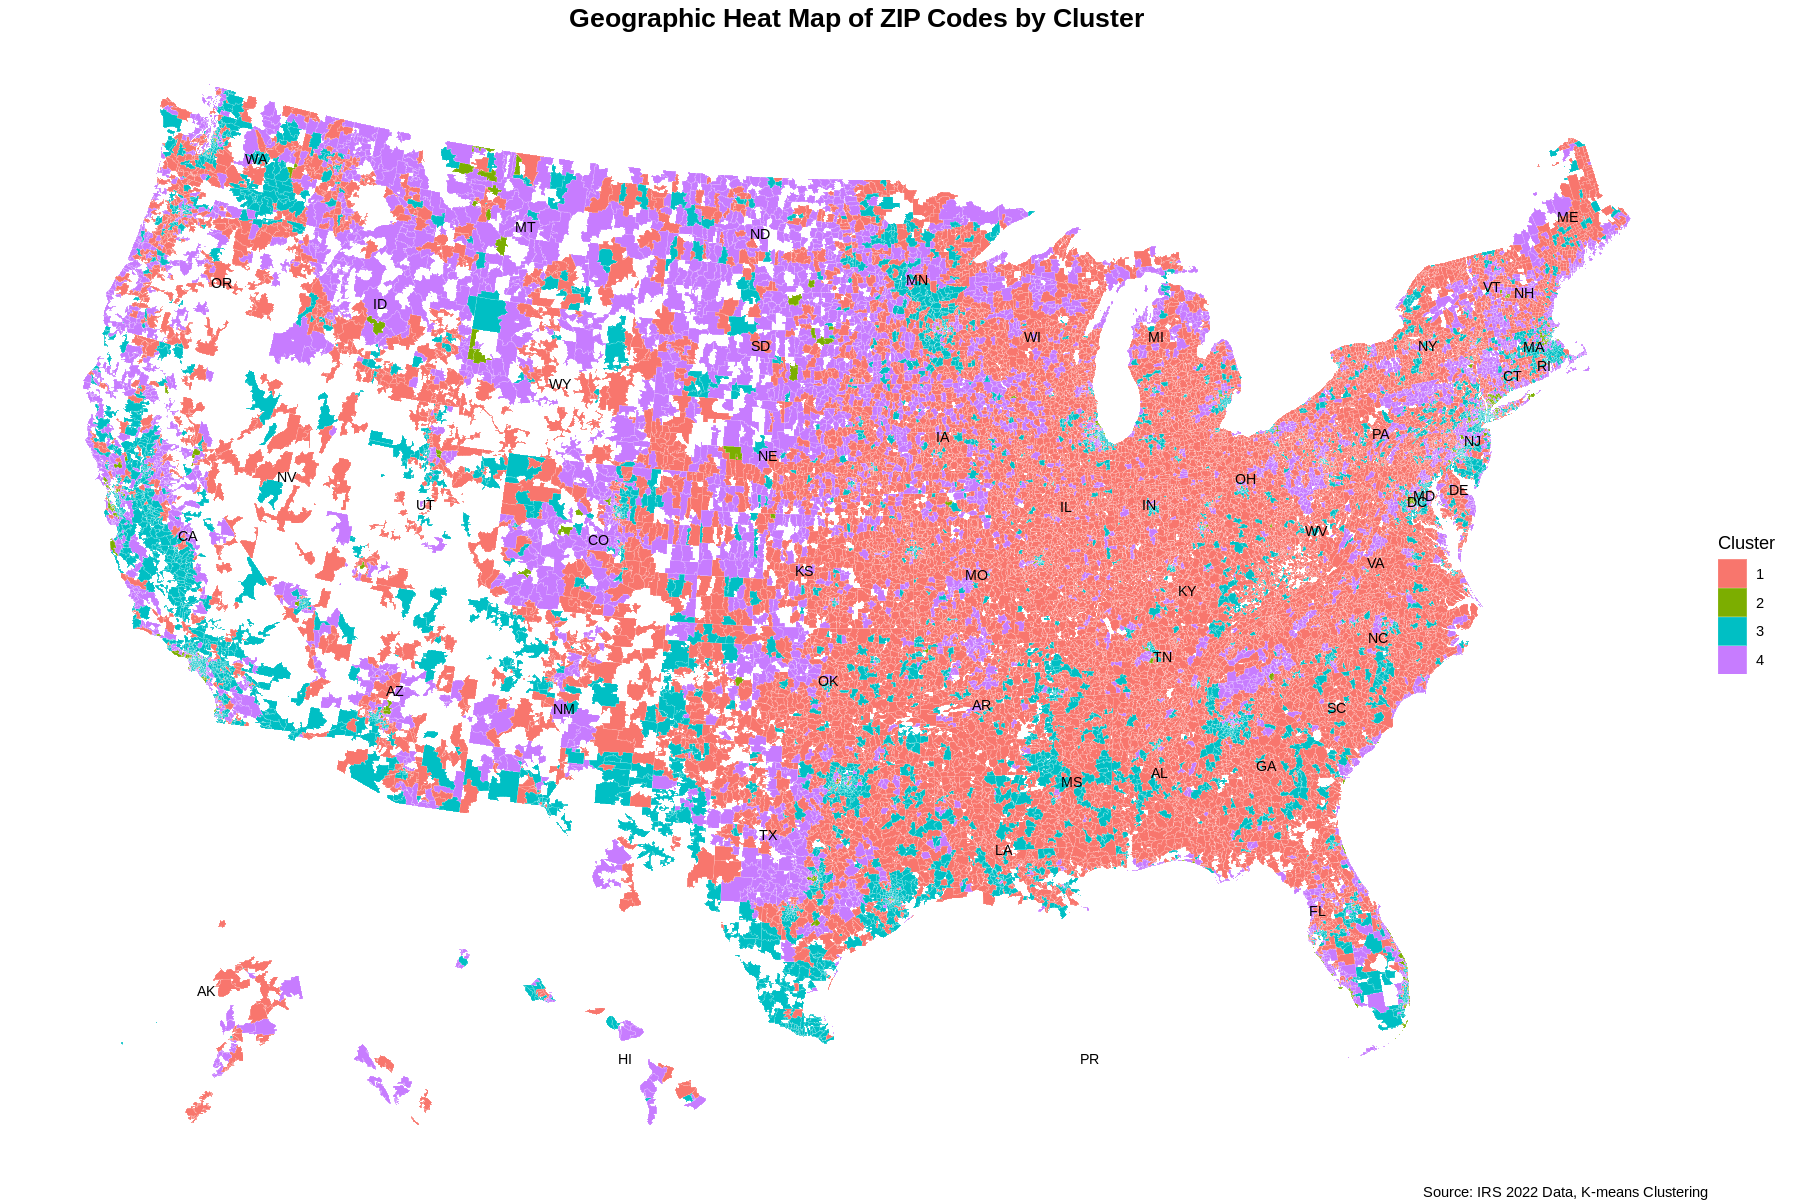

In [159]:
clustering_data_with_clusters$zipcode <- as.character(clustering_data_with_clusters$zipcode)

cluster_map_data <- zips_sf %>%
  left_join(clustering_data_with_clusters, by = c("GEOID" = "zipcode")) %>%
  filter(!is.na(cluster))

options(repr.plot.width = 15, repr.plot.height = 10)
ggplot(cluster_map_data) +
  geom_sf(aes(fill = as.factor(cluster)), color = "white", size = 0.05) +
  geom_sf_text(data = state_centroids, aes(label = STUSPS), size = 3, color = "black") +
  labs(title = "Geographic Heat Map of ZIP Codes by Cluster", caption = "Source: IRS 2022 Data, K-means Clustering", fill="Cluster") +
  theme_void() +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

### C. Summary of K-means Clustering Findings
***Important note: whenever the K-mean clustering code is run, it will rearrange the cluster number randomly. The insights generated below are based on the cluster assignment I received. The cluster number will change, but their size and interpretation hold true.***


After performing K-means clustering on ZIP code data using income and income source percentages, four distinct clusters were identified, each representing a unique economic profile:

*   **Cluster 1: Mid-Income, High Salary Dependence (51.2 avg. income, 81.0% salary), cluster size of 6,297.**
    *   **Characteristics**: This cluster has a moderate average income, and its income portfolio is heavily reliant on salaries and wages, with very low contributions from investment and business income. Retirement income is present but not a dominant factor. This suggests areas primarily composed of working-class and middle-class households with traditional employment.
    *   **Example**: General residential areas, potentially including some rural or exurban communities, where employment is the main income driver.


*   **Cluster 2: High-Income, Investment-Oriented (329.0 avg. income, 22.6% investment), the smallest cluster of 419 zipcode.**
    *   **Characteristics**: This cluster is characterized by the highest average income, significantly higher than other clusters. While salary is still the primary income source, investment income constitutes a substantial portion, indicating a wealthier demographic likely engaged in significant financial activities. Business income also plays a notable role. This cluster represents affluent areas with a diverse income portfolio, leaning heavily towards investments.
    *   **Example**: ZIP codes in this cluster likely include urban centers or suburban areas with high net-worth individuals.


*   **Cluster 3: Lower-Mid Income, Balanced with Retirement (49.8 avg. income, 72.6% salary, 20.9% retirement), the biggest cluster of 14,953 zipcode.**
    *   **Characteristics**: This cluster has the lowest average income among the groups. While salary is still significant, retirement income contributes a proportionally higher share compared to other clusters, alongside a moderate share from business. Investment and unemployment percentages are low. This cluster likely includes areas with a higher proportion of retirees or older populations, possibly combined with working households.
    *   **Example**: Retirement communities, small towns, or regions with an aging population and a mix of blue-collar and service industry jobs.

*   **Cluster 4: Upper-Middle Income, Salary-Dominant (77.2 avg. income, 61.0% salary), cluster size of 5,919.**
    *   **Characteristics**: This cluster represents an upper-middle-income bracket. Salary is the most dominant income source, but investment and business income are more significant here compared to clusters 1 and 3. This cluster suggests areas with well-compensated professionals and a decent level of supplementary income from non-salary sources.
    *   **Example**: Established suburban communities or areas with a strong presence of skilled labor and professionals.

### D. Insights:

1.   The Income heat map provides a starting-point for companies to target ZIP code or build their DMA mapping based on average income, a more granular approach than looking at the entire state level of economic status.
2. The identified clusters provide a robust framework for demographic segmentation, enabling more targeted marketing strategies and a deeper understanding of economic disparities at the ZIP code level.
3.   Further analysis of the geographic distribution of these clusters can uncover regional economic patterns and potential correlations with other socio-economic factors.

## **VI. LLM Usage**


*   **LLM tool:** Gemini
*   **Use Cases:**
    * Data Exploration: This dataset includes complicated tax code and tax filing structure, which requires a deep understanding of tax accounting to accurately analyze this data. Gemini helped me understand the tax coding system, categories meaning, data reporting process and data interpretation.
      * Due to the public availability of tax filing practice and data source, Gemini was able to accuratey interprete the meaning of each category and also some complex coding (Zip code 99999, different types of Income sources, how Income is calculated with both gains and losses, etc.)
    * Heat Map creation: Gemini was able to generate codes that create a Heat Map based on my goal and description.
      * Strength:
        * The map was created quickly with a simple prompt, and Gemini scans the entire document to understand the project in addition to just my prompts.
        * I was also able to iterate the map fairly easily to include different level of detail and customizing aesthetic.
        * The generated code includes comment to explain each line of code and its purpose.
      * Improvement Areas: The built-in Gemini function on Colab seems to take longer to process and generate code.
        * I tried to create an interactive heat map with ZIP code level of data, but it seemed that Colab wasn't able to run it due to the limited RAM capacity.
    * K-mean clustering: Gemini ran the entire K-mean clustering process based on the goal and variables that I provided.
        * Strength: whenever Gemini ran into any issue with data prepartion or manipulation for the clustering process, it self-diagnosed and came up with a solution on its own. Gemini also explained all the steps and solutions on markdown to help me understand each step of the process, that is how I was able to follow and audit its process.

* **Final Thought:** the biggest learning I took from using LLM for this project is LLM is a genius assistant to support and develop an analysis plan that I produced.
  * I was able to create complicated maps that support and confirm my hypothesis, which also provide a visual illustration for readers' easy understanding.
  * K-mean clsutering is a method that would take hours for me to learn and apply corectly. LLM fastened the process and reduced my work time so that I can focus on data interpretation and insight development.






